# Lotka Volterra (1 parameter1) test case  

OK

In [1]:
######### LIBRARIES ############
import keras.backend as K
from keras.regularizers import l2
from hyperopt import STATUS_OK, tpe, Trials, hp, fmin
from hyperopt.pyll.stochastic import sample
from sklearn.model_selection import KFold
from keras.models import save_model
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
from keras.optimizers import Adam, Nadam, Adamax
from time import perf_counter
import pandas
import pickle
import os
import keras
import tensorflow as tf
import sys
from module_utils import * 
sys.path.append('../utils')
from Structure import *

from data_collection import *
from pathlib import Path

# path to the current notebook
current_file_path = Path().resolve()
# path to the current folder
load_context_functions(current_file_path.parent.name)


True

In [2]:
# reproducibility
seed = 7
np.random.seed(seed)
keras.utils.set_random_seed(seed)
tf.random.set_seed(seed)

In [3]:
solver_HF = System1()
solver_LF = System1()

mu_values = np.linspace(1, 5, 9)
params = [(mu,) for mu in mu_values]

(t_HF,y_HF,mu_HF)=solver_HF.generate_dataset(T=8.0, params=np.array(params), h=0.02, fidelity='HF')
solver_HF.save_dataset('dataset_HF.h5')

(t_LF,y_LF,mu_LF)=solver_LF.generate_dataset(T=8.0, params=np.array(params), h=0.05, fidelity='LF')
solver_LF.save_dataset('dataset_LF.h5')


In [4]:
solver_valHF = System1()
solver_valLF = System1()

mu_values_val = np.linspace(1, 5, 6)
params_val = [(mu,) for mu in mu_values_val]

(t_valhf,y_valhf,mu_valhf)=solver_valHF.generate_dataset(T=8.0, params=np.array(params_val), h=0.02, fidelity='HF')
solver_valHF.save_dataset('dataset_HF.h5')

(t_valLF,y_valLF,mu_valLF)=solver_valLF.generate_dataset(T=8.0, params=np.array(params_val), h=0.05, fidelity='LF')
solver_valLF.save_dataset('dataset_LF.h5')

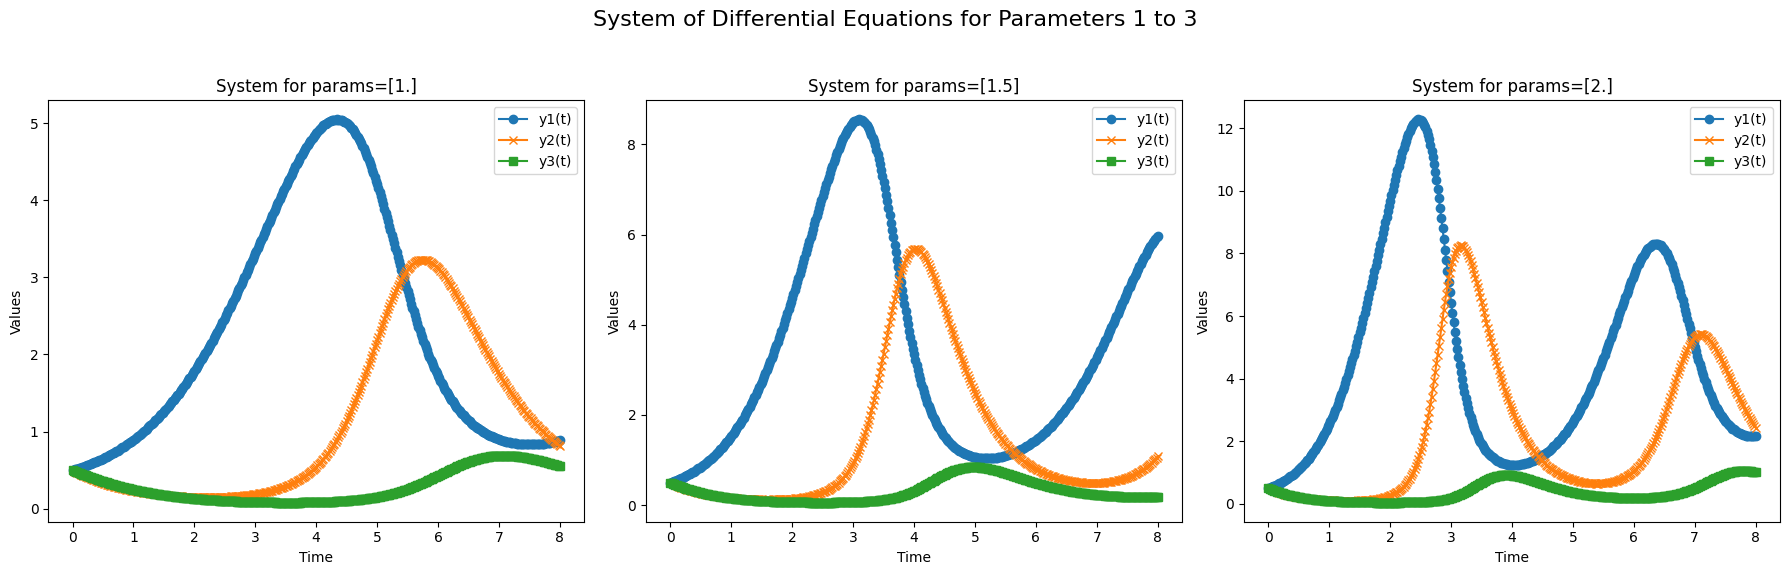

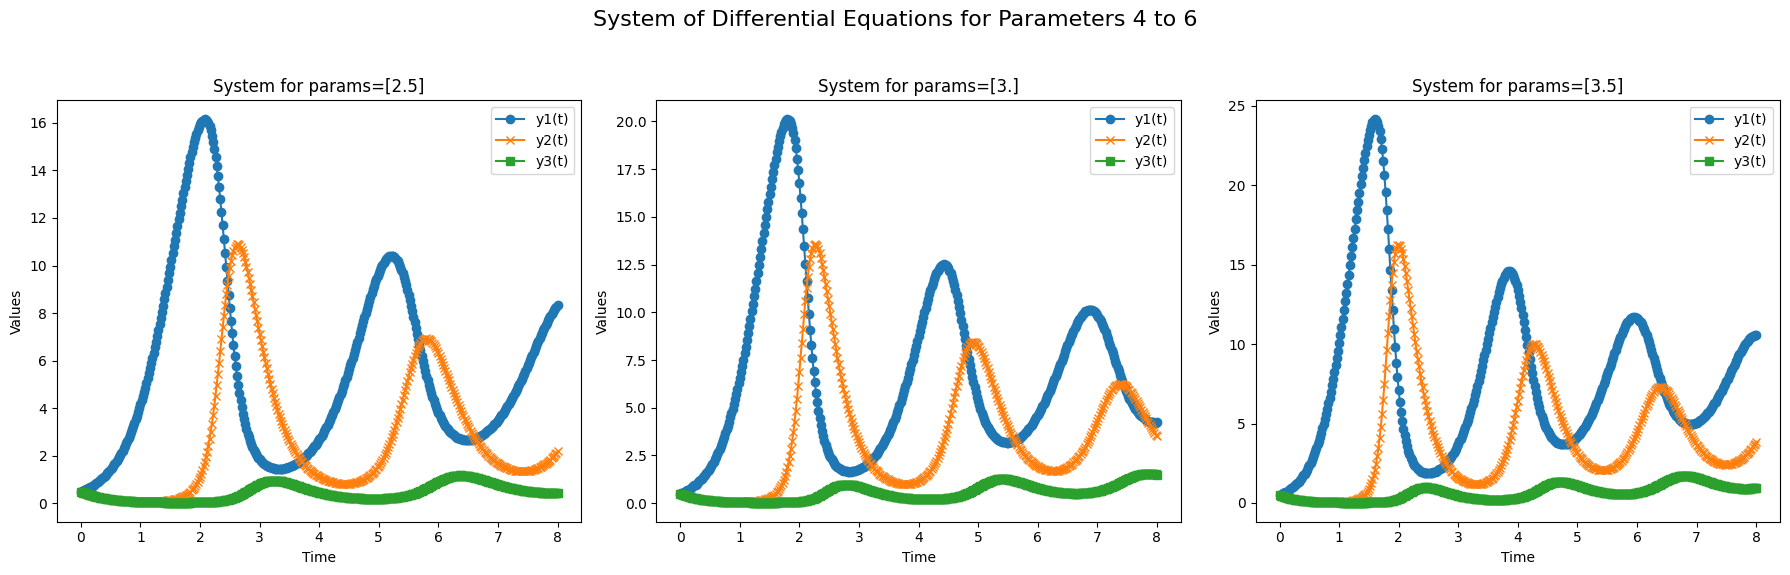

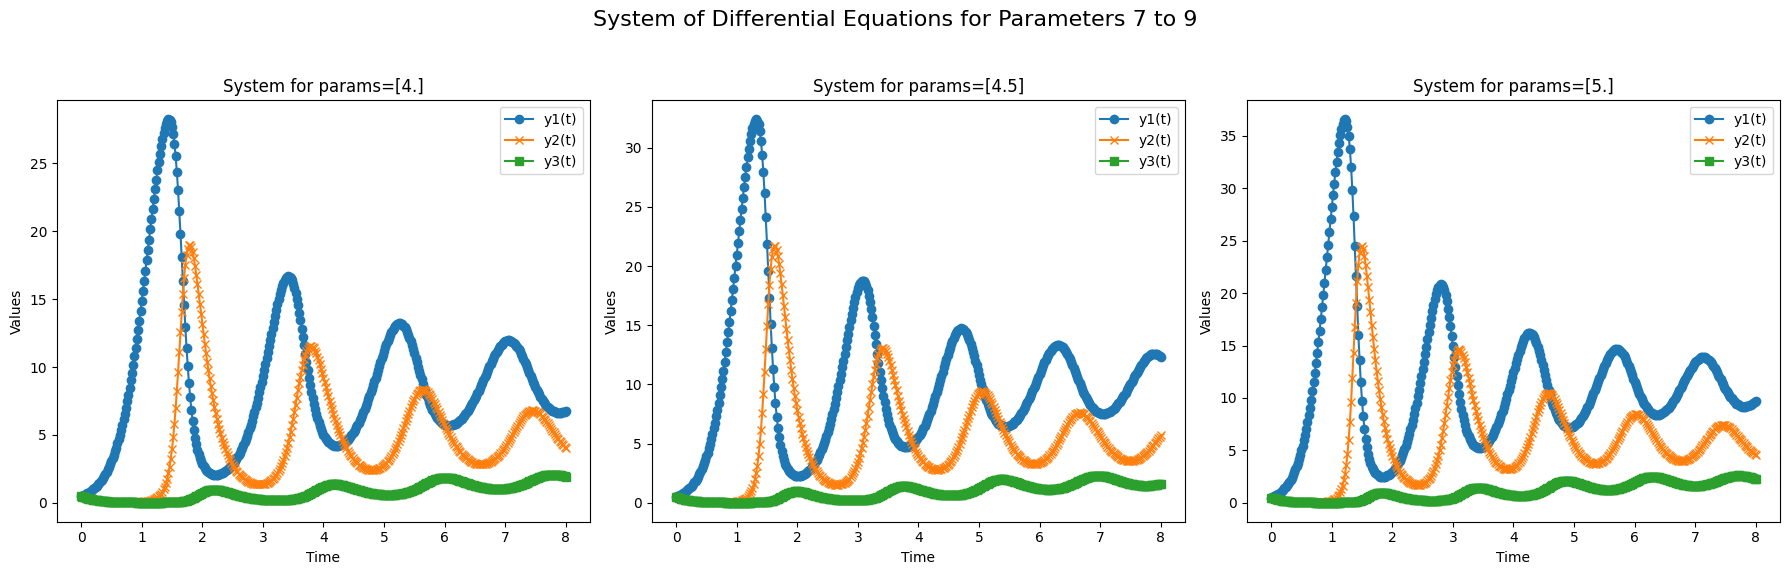

In [5]:
solver_HF.plot_results()

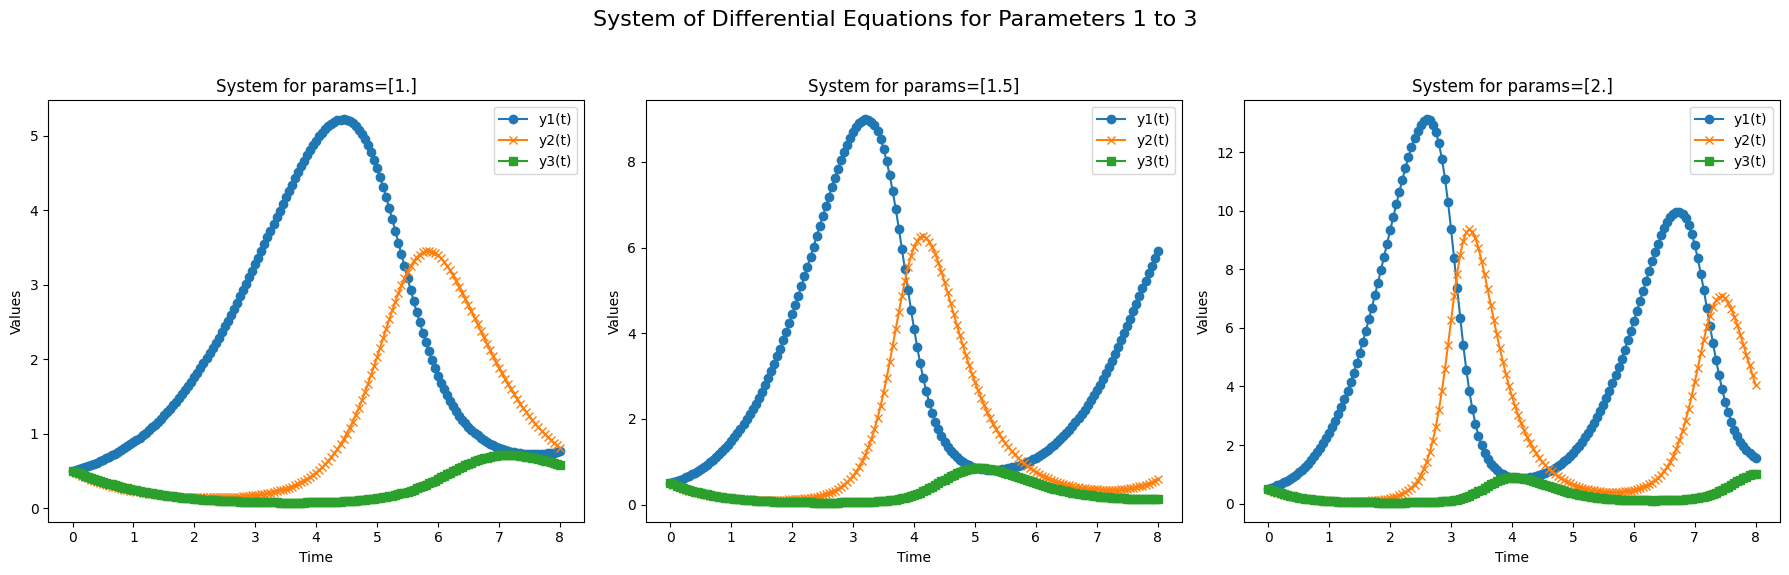

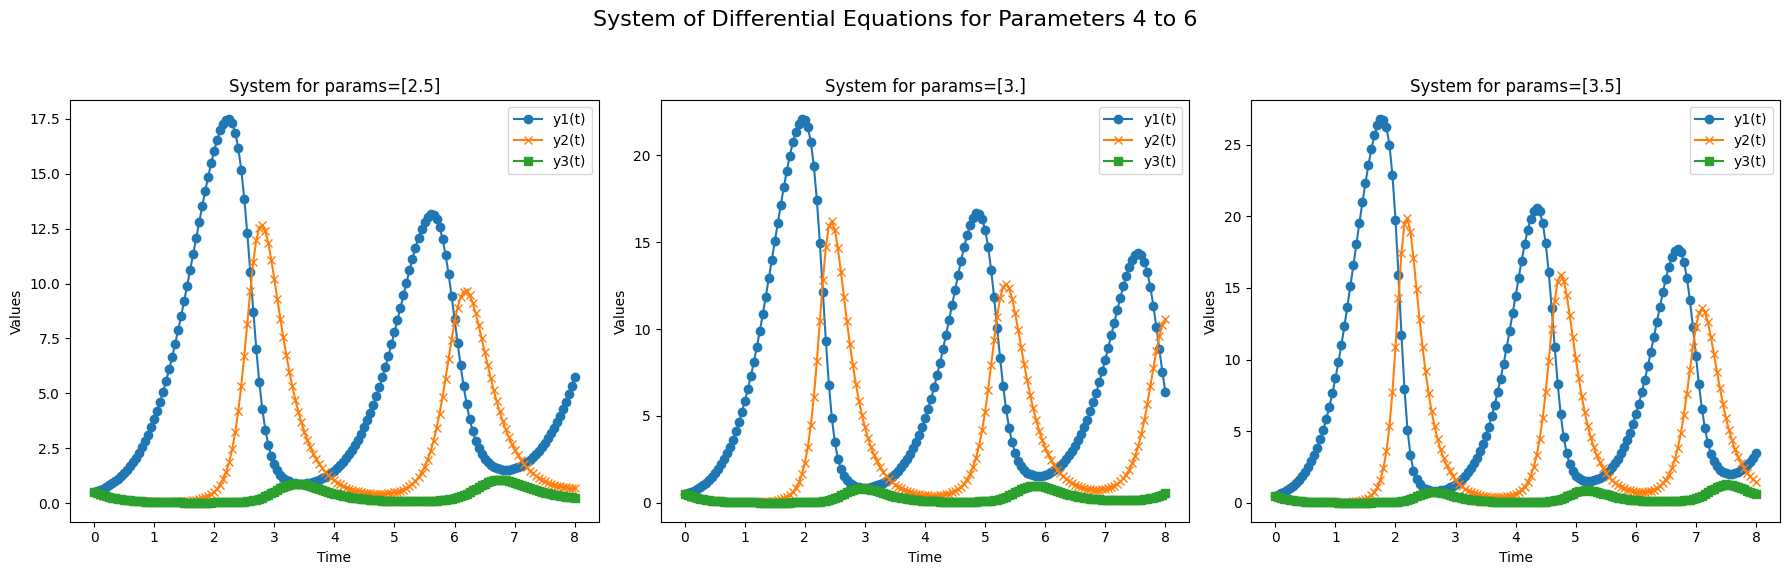

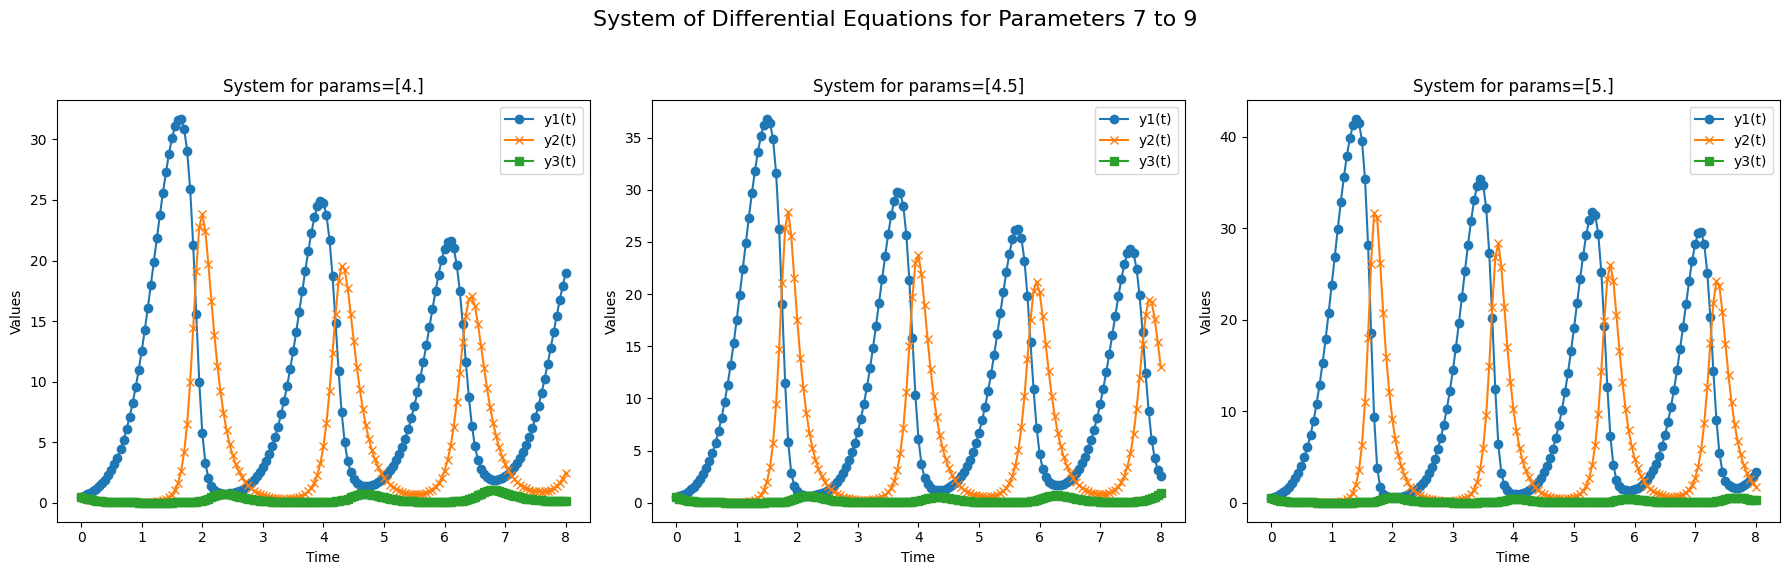

In [6]:
solver_LF.plot_results()

In [7]:

x_HF=np.array(np.meshgrid(mu_HF,t_HF)).T.reshape(-1, 2)[:,[1,0]]
x_LF=np.array(np.meshgrid(mu_LF,t_LF)).T.reshape(-1, 2)[:,[1,0]]


x_valHF=np.array(np.meshgrid(mu_valhf,t_valhf)).T.reshape(-1, 2)[:,[1,0]]
x_valLF=np.array(np.meshgrid(mu_valLF,t_valLF)).T.reshape(-1, 2)[:,[1,0]]


In [8]:
y_HF=np.array(y_HF).reshape(-1, 3)
y_LF=np.array(y_LF).reshape(-1, 3)

y_valHF=np.array(y_valhf).reshape(-1, 3)
y_valLF=np.array(y_valLF).reshape(-1, 3)

In [9]:
n_LF=1000
indices_LF = np.random.permutation(x_LF.shape[0])[:n_LF]

n_HF=2000
indices_HF = np.random.permutation(x_HF.shape[0])[:n_HF]

n_valLF=800
indices_valLF = np.random.permutation(x_valLF.shape[0])[:n_valLF]

n_valHF=1600
indices_valHF = np.random.permutation(x_valHF.shape[0])[:n_valHF]

[I 2024-08-19 14:52:14,711] A new study created in RDB with name: no-name-0f4187f0-ae22-49e9-9342-602ad93043b8
[I 2024-08-19 14:54:02,533] Trial 8 finished with value: 14.080360217428822 and parameters: {'nodes': 20, 'l2weight': 0.05650978185914996, 'lr': 0.005675343775858474, 'kernel_init': 'glorot_uniform', 'opt': 'Adamax'}. Best is trial 8 with value: 14.080360217428822.
[I 2024-08-19 14:54:03,636] Trial 7 finished with value: 26.602191355139038 and parameters: {'nodes': 6, 'l2weight': 0.00010132766580545921, 'lr': 0.0003046307952772018, 'kernel_init': 'glorot_uniform', 'opt': 'Adamax'}. Best is trial 6 with value: 10.241125400301735.
[I 2024-08-19 14:54:03,648] Trial 6 finished with value: 10.241125400301735 and parameters: {'nodes': 4, 'l2weight': 0.014366007275843307, 'lr': 0.021549351095386374, 'kernel_init': 'glorot_uniform', 'opt': 'Adam'}. Best is trial 6 with value: 10.241125400301735.
[I 2024-08-19 14:54:03,666] Trial 3 finished with value: 19.31599559266206 and parameters:

New parameters identified during HPO:
{'kernel_init': 'uniform',
 'l2weight': 0.0015902185943731835,
 'lr': 0.010824546558751915,
 'nodes': 7,
 'opt': 'Adam'}
The function training took 16.438187 seconds.


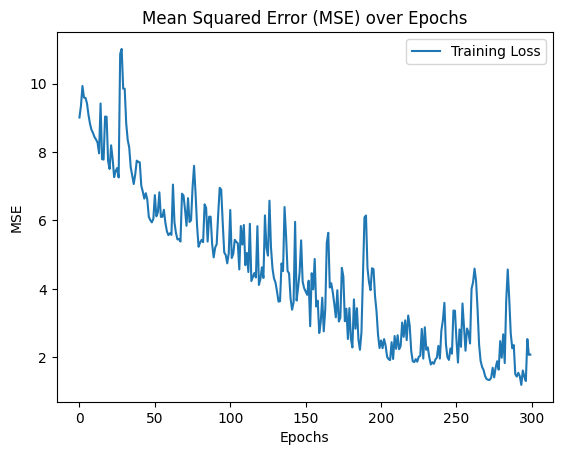

[I 2024-08-19 14:58:03,693] A new study created in RDB with name: no-name-f4f3f4fa-d7ff-4e40-876e-75754035c6ae
[I 2024-08-19 14:59:24,191] Trial 4 finished with value: 3.7358638871931724 and parameters: {'nodes': 4, 'l2weight': 0.06833526552239458, 'lr': 0.08985371272087804, 'kernel_init': 'uniform', 'opt': 'Adamax'}. Best is trial 4 with value: 3.7358638871931724.
[I 2024-08-19 14:59:24,198] Trial 1 finished with value: 10.074923890953066 and parameters: {'nodes': 16, 'l2weight': 0.059686850737761324, 'lr': 0.0006132260316069335, 'kernel_init': 'glorot_uniform', 'opt': 'Adam'}. Best is trial 4 with value: 3.7358638871931724.
[I 2024-08-19 14:59:24,245] Trial 0 finished with value: 0.8542013812305547 and parameters: {'nodes': 23, 'l2weight': 0.0011925901702351791, 'lr': 0.06319259096973116, 'kernel_init': 'glorot_uniform', 'opt': 'Adam'}. Best is trial 0 with value: 0.8542013812305547.
[I 2024-08-19 14:59:26,521] Trial 6 finished with value: 21.368291417125967 and parameters: {'nodes':

New parameters identified during HPO:
{'kernel_init': 'glorot_uniform',
 'l2weight': 0.00012541532994939157,
 'lr': 0.02007377317859368,
 'nodes': 29,
 'opt': 'Adam'}
The function training took 118.102753 seconds.


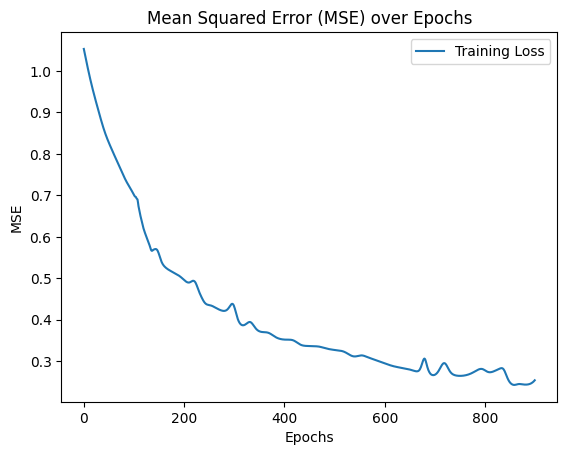

Test MSE: 0.26079498243029076
R^2: 0.9877529127771872


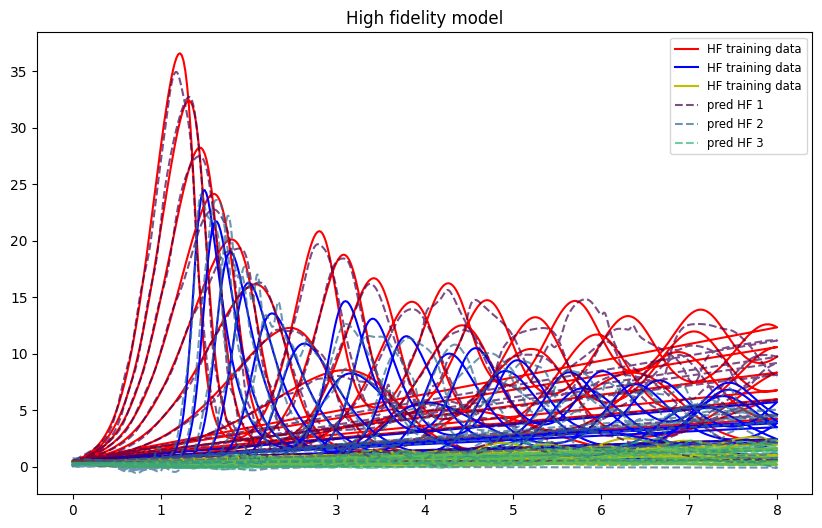

In [14]:
N=[400,1000]
n=[200,250]
names = ['LF', 'HF']

# parameters 
bestLF_params =  {
                  'nodes': 22, 
                  'l2weight': 0.028048305749058373, 
                  'lr': 0.013287693311036268, 
                  'kernel_init': 'glorot_uniform', 
                  'opt': 'Adam'
                  }
best_params= {
              'nodes': 58, 
              'l2weight': 0.0014109037104195455, 
              'lr': 0.07556528693019551, 
              'kernel_init': 'glorot_uniform', 
              'opt': 'Adamax'
              }

params_NN=[bestLF_params, best_params]


# collection of the parameters
definition_2steps = {
    "network_type": "2step",
    "names": names,
    "params": params_NN,
    "data_train": [x_LF[indices_LF,:],x_HF[indices_HF,:]],
    "output_train": [y_LF[indices_LF,:], y_HF[indices_HF,:]],
    "data_val": [x_valLF[indices_valLF,:],x_valHF[indices_valHF,:]],
    "output_val": [y_valLF[indices_valLF,:], y_valHF[indices_valHF,:]],    
    "N": N,
    "n": n,
    "train": True,
    "do_HPO": True,
    "verbose": False
}

final_model_trained = NetworkFactory.build_network(**definition_2steps)

solver_test=System1()
mu_values_test = np.linspace(1, 5, 15)
params_test = [(mu,) for mu in mu_values_test]
(t_test,y_test,mu_test)=solver_test.generate_dataset(T=8.0, params=np.array(params), h=0.005, fidelity='HF')
solver_test.save_dataset('dataset_test.h5')

datatest=np.array(np.meshgrid(mu_test, t_test)).T.reshape(-1, 2)[:,[1,0]]

y_test_pred=final_model_trained.prediction(datatest)

(mse_MF,R_MF)=final_model_trained.performance(datatest,np.array(y_test).reshape(-1,3))


# Example: Improving the plot by using transparency, a colormap, and reduced marker size
plt.figure(figsize=(10, 6))

# Plotting the training data with smaller markers
plt.plot(x_HF[:, 0], y_HF[:,0], 'r-', label='HF training data', markersize=2)
plt.plot(x_HF[:, 0], y_HF[:,1], 'b-', label='HF training data', markersize=2)
plt.plot(x_HF[:, 0], y_HF[:,2], 'y-', label='HF training data', markersize=2)

# Plotting the prediction data with transparency and a colormap
for i in range(y_test_pred.shape[1]):
    plt.plot(datatest[:, 0], y_test_pred[:, i], '--', color=plt.cm.viridis(i/y_test_pred.shape[1]), alpha=0.7, label=f'pred HF {i+1}')

# Adding legend and title
plt.legend(loc='best', fontsize='small')
plt.title('High fidelity model')

# Show the plot
plt.show()


The function training took 9.862371 seconds.


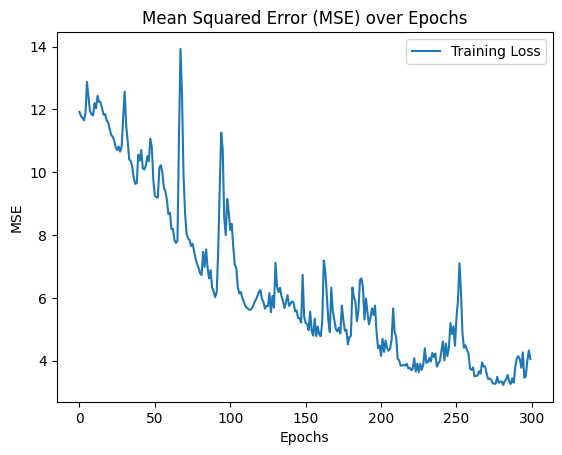

The function training took 21.829796 seconds.


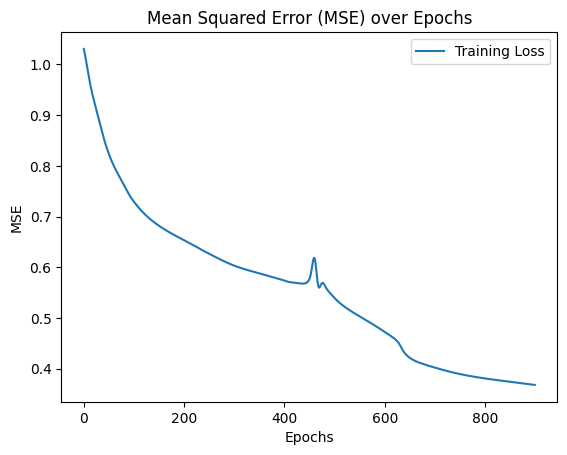

Test MSE: 0.37192792354805876
R^2: 0.9825340438767443


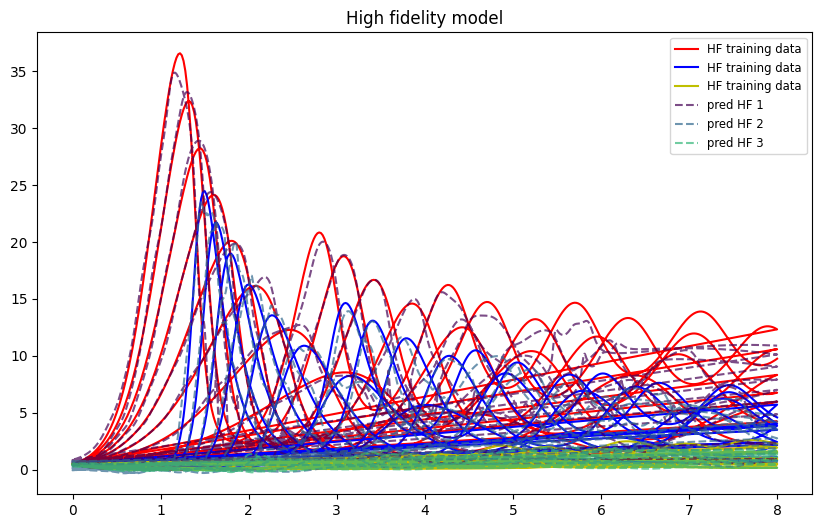

In [10]:
N=[400,1000]
n=[200,250]
names = ['LF', 'HF']

# parameters 
bestLF_params =  {'kernel_init': 'uniform',
 'l2weight': 0.0015902185943731835,
 'lr': 0.010824546558751915,
 'nodes': 7,
 'opt': 'Adam'}
best_params={'kernel_init': 'glorot_uniform',
 'l2weight': 0.00012541532994939157,
 'lr': 0.02007377317859368,
 'nodes': 29,
 'opt': 'Adam'}

params_NN=[bestLF_params, best_params]


# collection of the parameters
definition_2steps = {
    "network_type": "2step",
    "names": names,
    "params": params_NN,
    "data_train": [x_LF[indices_LF,:],x_HF[indices_HF,:]],
    "output_train": [y_LF[indices_LF,:], y_HF[indices_HF,:]],
    "data_val": [x_valLF[indices_valLF,:],x_valHF[indices_valHF,:]],
    "output_val": [y_valLF[indices_valLF,:], y_valHF[indices_valHF,:]],    
    "N": N,
    "n": n,
    "train": True,
    "do_HPO": False,
    "verbose": False
}

final_model_trained = NetworkFactory.build_network(**definition_2steps)

solver_test=System1()
mu_values_test = np.linspace(1, 5, 15)
params_test = [(mu,) for mu in mu_values_test]
(t_test,y_test,mu_test)=solver_test.generate_dataset(T=8.0, params=np.array(params), h=0.005, fidelity='HF')
solver_test.save_dataset('dataset_test.h5')

datatest=np.array(np.meshgrid(mu_test, t_test)).T.reshape(-1, 2)[:,[1,0]]

y_test_pred=final_model_trained.prediction(datatest)

(mse_MF,R_MF)=final_model_trained.performance(datatest,np.array(y_test).reshape(-1,3))


# Example: Improving the plot by using transparency, a colormap, and reduced marker size
plt.figure(figsize=(10, 6))

# Plotting the training data with smaller markers
plt.plot(x_HF[:, 0], y_HF[:,0], 'r-', label='HF training data', markersize=2)
plt.plot(x_HF[:, 0], y_HF[:,1], 'b-', label='HF training data', markersize=2)
plt.plot(x_HF[:, 0], y_HF[:,2], 'y-', label='HF training data', markersize=2)

# Plotting the prediction data with transparency and a colormap
for i in range(y_test_pred.shape[1]):
    plt.plot(datatest[:, 0], y_test_pred[:, i], '--', color=plt.cm.viridis(i/y_test_pred.shape[1]), alpha=0.7, label=f'pred HF {i+1}')

# Adding legend and title
plt.legend(loc='best', fontsize='small')
plt.title('High fidelity model')

# Show the plot
plt.show()


Test MSE: 0.3760049613659394
R^2: 0.9820748156703114


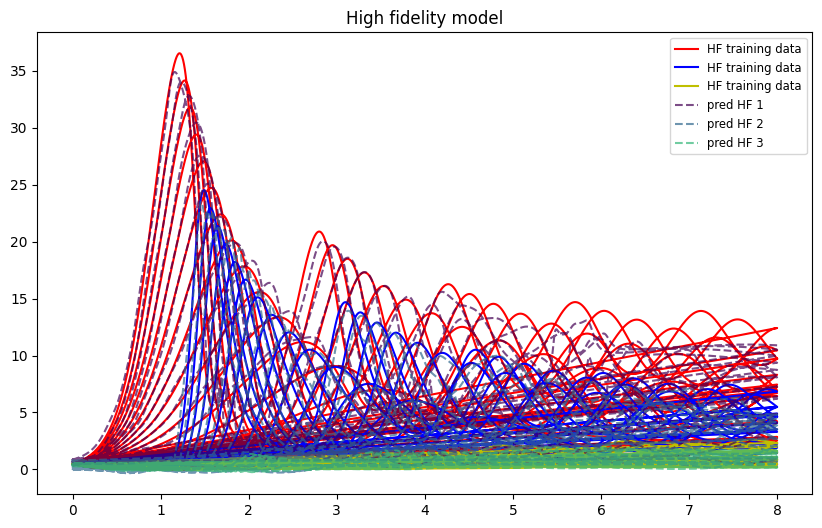

: 

In [11]:
(t_test,y_test,mu_test)=solver_test.generate_dataset(T=8.0, params=np.array(params_test), h=0.005, fidelity='HF')
solver_test.save_dataset('dataset_test.h5')

datatest=np.array(np.meshgrid(mu_test, t_test)).T.reshape(-1, 2)[:,[1,0]]

y_test_pred=final_model_trained.prediction(datatest)

(mse_MF,R_MF)=final_model_trained.performance(datatest,np.array(y_test).reshape(-1,3))


# Example: Improving the plot by using transparency, a colormap, and reduced marker size
plt.figure(figsize=(10, 6))

# Plotting the training data with smaller markers
plt.plot(datatest[:, 0], np.array(y_test).reshape(-1,3)[:,0], 'r-', label='HF training data', markersize=2)
plt.plot(datatest[:, 0], np.array(y_test).reshape(-1,3)[:,1], 'b-', label='HF training data', markersize=2)
plt.plot(datatest[:, 0], np.array(y_test).reshape(-1,3)[:,2], 'y-', label='HF training data', markersize=2)

# Plotting the prediction data with transparency and a colormap
for i in range(y_test_pred.shape[1]):
    plt.plot(datatest[:, 0], y_test_pred[:, i], '--', color=plt.cm.viridis(i/y_test_pred.shape[1]), alpha=0.7, label=f'pred HF {i+1}')

# Adding legend and title
plt.legend(loc='best', fontsize='small')
plt.title('High fidelity model')

# Show the plot
plt.show()

In [13]:
np.unique(datatest[:,1])

array([1.        , 1.28571429, 1.57142857, 1.85714286, 2.14285714,
       2.42857143, 2.71428571, 3.        , 3.28571429, 3.57142857,
       3.85714286, 4.14285714, 4.42857143, 4.71428571, 5.        ])

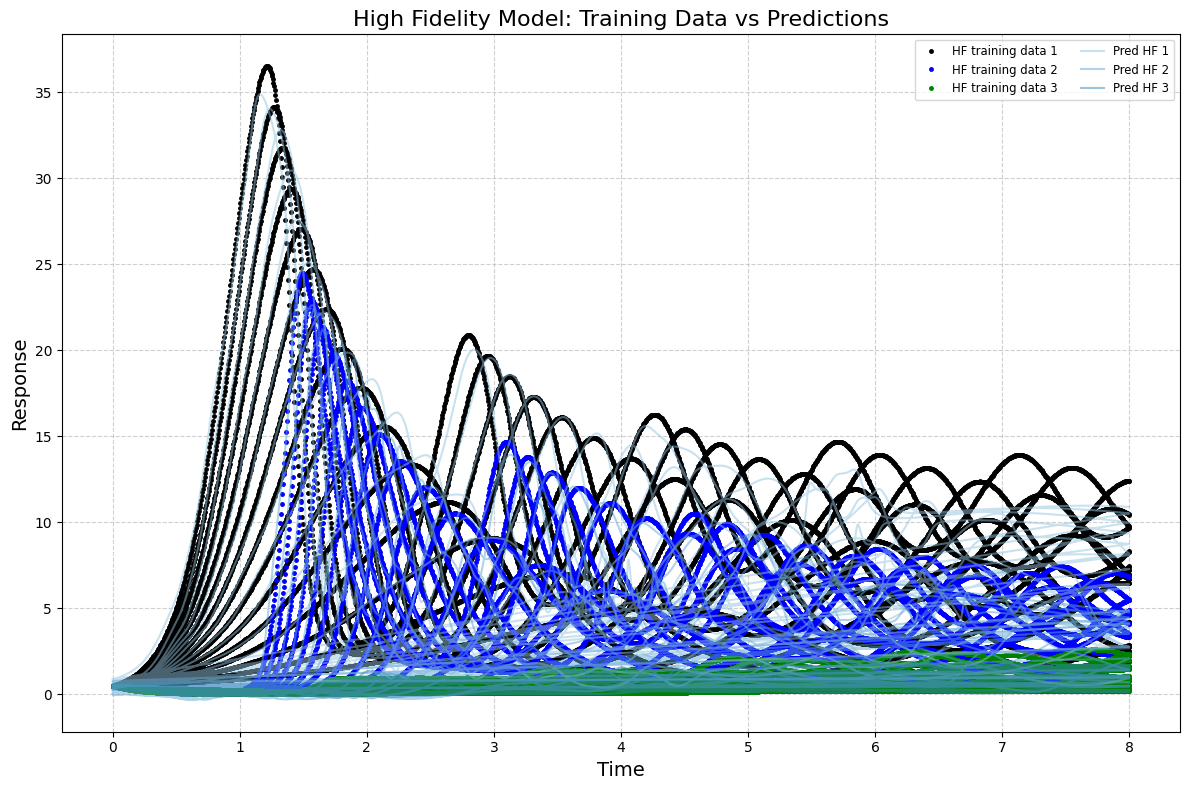

In [14]:
plt.figure(figsize=(12, 8))

# Plotting the training data with darker markers
plt.plot(datatest[:, 0],np.array(y_test).reshape(-1,3)[:, 0], 'k.', label='HF training data 1', markersize=5)  # Nero
plt.plot(datatest[:, 0], np.array(y_test).reshape(-1,3)[:, 1], 'b.', label='HF training data 2', markersize=5)  # Blu scuro
plt.plot(datatest[:, 0], np.array(y_test).reshape(-1,3)[:, 2], 'g.', label='HF training data 3', markersize=5)  # Verde scuro

# Plotting the prediction data with lighter, less fluorescent colors
for i in range(y_test_pred.shape[1]):
    plt.plot(datatest[:, 0], y_test_pred[:, i], '-', 
             color=plt.cm.Blues(0.4 + 0.4 * i / y_test_pred.shape[1]),  # Gamma di blu meno vividi
             alpha=0.5, label=f'Pred HF {i+1}', linewidth=1.5)  # Trasparenza ridotta e linee più sottili

# Adding grid to the plot
plt.grid(True, linestyle='--', alpha=0.6)

# Adding labels to the axes
plt.xlabel('Time', fontsize=14)
plt.ylabel('Response', fontsize=14)

# Enhancing the title
plt.title('High Fidelity Model: Training Data vs Predictions', fontsize=16)

# Improving the legend
plt.legend(loc='best', fontsize='small', ncol=2)

# Adjusting the layout for better spacing
plt.tight_layout()

# Show the plot
plt.show()

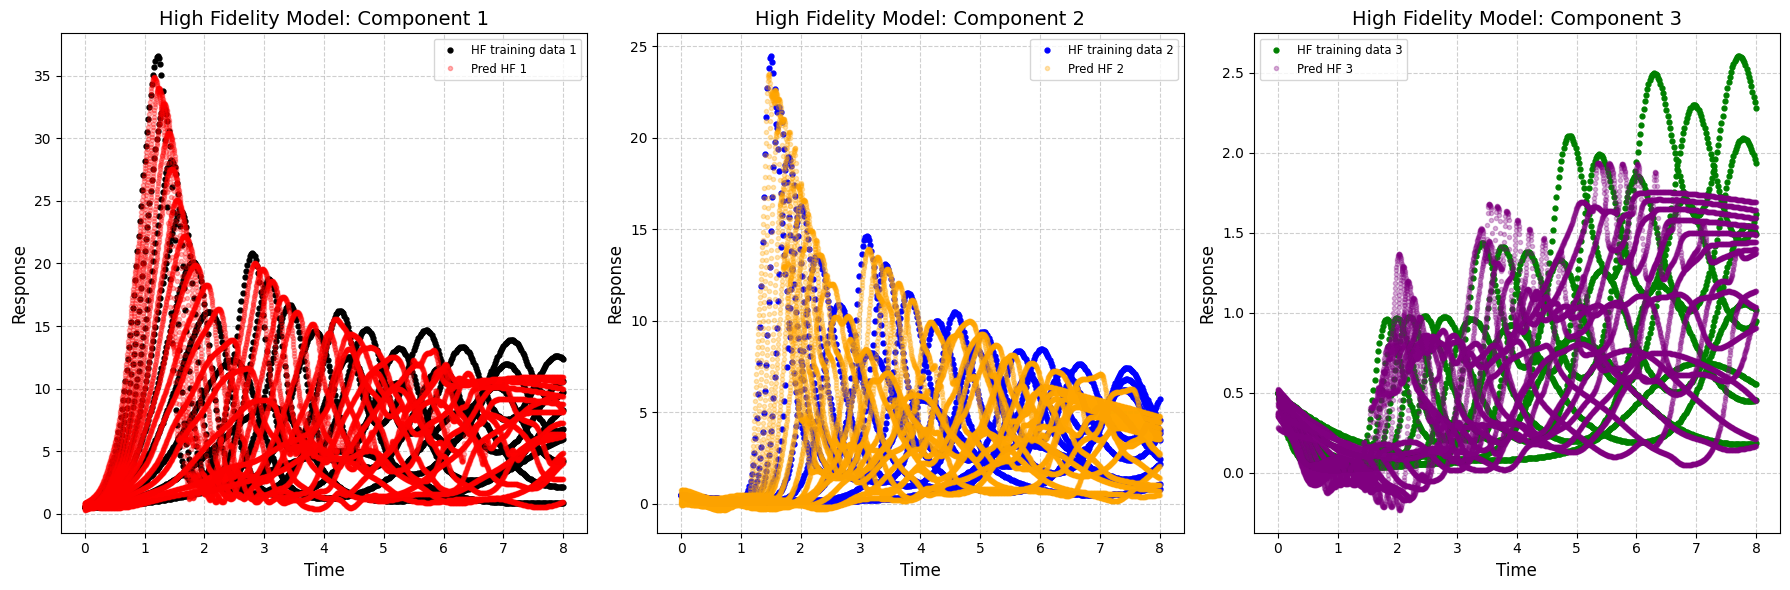

In [15]:
components = ['Component 1', 'Component 2', 'Component 3']
colors_training = ['k', 'b', 'g']  # Nero, Blu scuro, Verde scuro
colors_pred = ['r', 'orange', 'purple']  # Rosso, Arancione, Viola

plt.figure(figsize=(18, 6))

# Loop through each component to create a separate plot
for i in range(3):
    plt.subplot(1, 3, i + 1)  # Create a subplot (1 row, 3 columns)
    
    # Plotting the training data for the i-th component
    plt.plot(x_HF[:, 0], y_HF[:, i], f'{colors_training[i]}.', label=f'HF training data {i + 1}', markersize=7)

    # Plotting the prediction data for the i-th component
    plt.plot(datatest[:, 0], y_test_pred[:, i], '.', 
             color=colors_pred[i], alpha=0.3, label=f'Pred HF {i + 1}', linewidth=3)
    
    # Adding grid, labels, and title
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.xlabel('Time', fontsize=12)
    plt.ylabel('Response', fontsize=12)
    plt.title(f'High Fidelity Model: {components[i]}', fontsize=14)
    
    # Add a legend
    plt.legend(loc='best', fontsize='small')

# Adjust the layout and show the plot
plt.tight_layout()
plt.show()

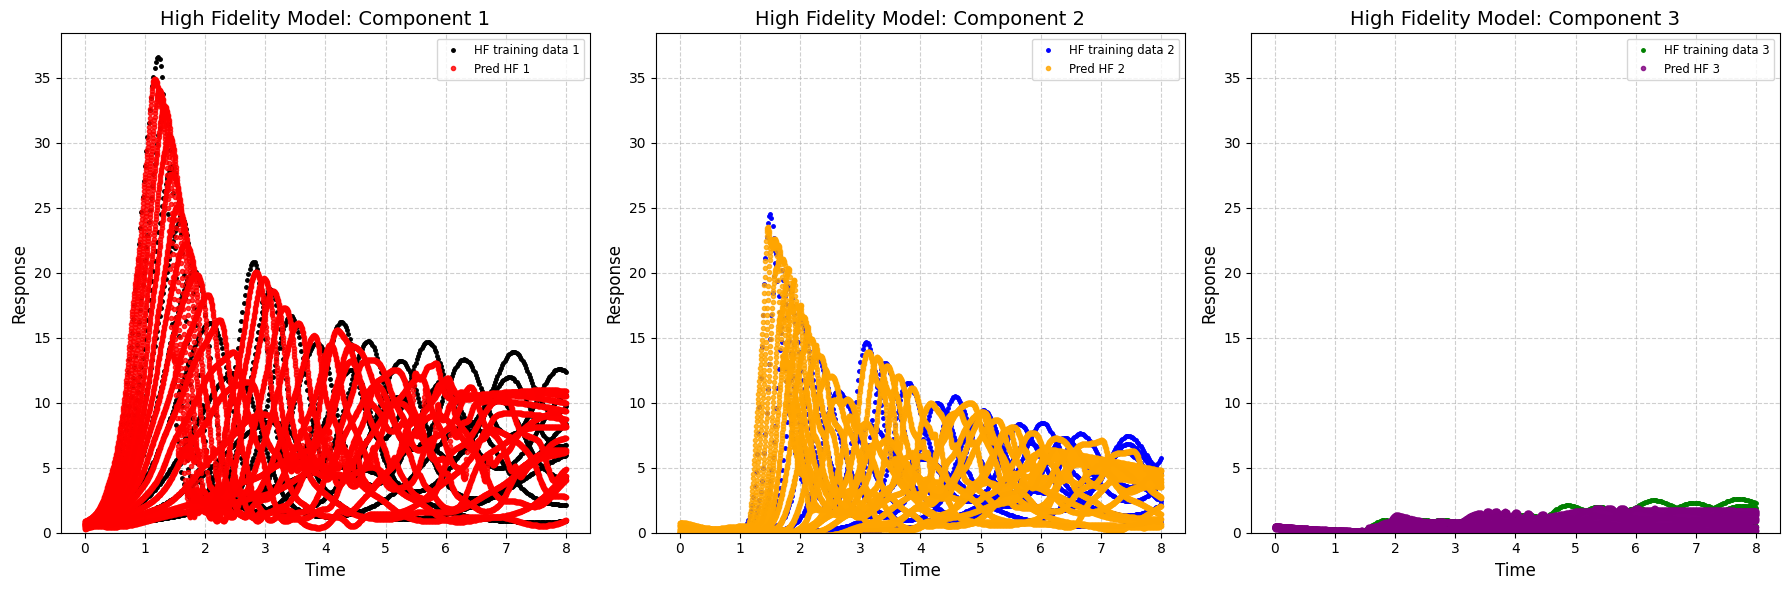

In [16]:
components = ['Component 1', 'Component 2', 'Component 3']
colors_training = ['k', 'b', 'g']  # Nero, Blu scuro, Verde scuro
colors_pred = ['r', 'orange', 'purple']  # Rosso, Arancione, Viola

# Calcola il massimo valore di y considerando tutti i dati (training e predizione)
max_y_value = max(np.max(y_HF), np.max(y_test_pred)) 
y_margin = 0.05 * max_y_value  # Aggiungi un margine del 5% al massimo valore

plt.figure(figsize=(18, 6))

# Loop through each component to create a separate plot
for i in range(3):
    plt.subplot(1, 3, i + 1)  # Create a subplot (1 row, 3 columns)
    
    # Plotting the training data for the i-th component
    plt.plot(x_HF[:, 0], y_HF[:, i], f'{colors_training[i]}.', label=f'HF training data {i + 1}', markersize=5)

    # Plotting the prediction data for the i-th component
    plt.plot(datatest[:, 0], y_test_pred[:, i], '.', 
             color=colors_pred[i], alpha=0.8, label=f'Pred HF {i + 1}', linewidth=1.5)
    
    # Imposta il limite dell'asse y
    plt.ylim(0, max_y_value + y_margin)
    
    # Adding grid, labels, and title
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.xlabel('Time', fontsize=12)
    plt.ylabel('Response', fontsize=12)
    plt.title(f'High Fidelity Model: {components[i]}', fontsize=14)
    
    # Add a legend
    plt.legend(loc='best', fontsize='small')

# Adjust the layout and show the plot
plt.tight_layout()
plt.show()

# Bayesian inverse problem

|   iter    |  target   |  n_data   | rwmh_s... |   sigma   | sigma_... |
-------------------------------------------------------------------------
Sampling 2 chains in parallel


2024-08-22 04:49:48,432	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  5.055  0.063   4.947    5.171      0.004    0.003     291.0     361.0   

    r_hat  
x0   1.02  
Estimated values are [5.055]
The difference between estimated values [0.055]



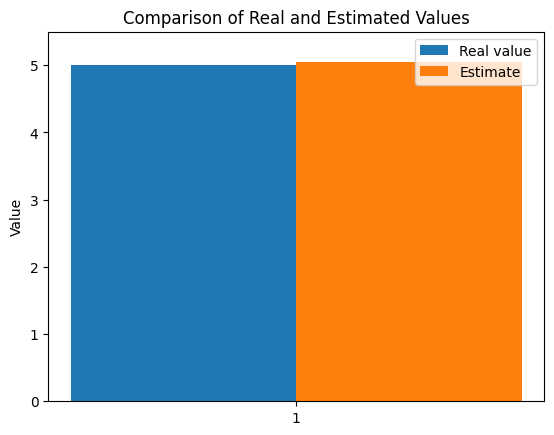

The function param_inverse took 220.576280 seconds.
| 1         | -0.011    | 37.49     | 1.926     | 3.196     | 0.3997    |
Sampling 2 chains in parallel


2024-08-22 04:53:28,070	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean    sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  5.042  0.02   5.007    5.077      0.001    0.001     239.0     229.0   

    r_hat  
x0   1.01  
Estimated values are [5.042]
The difference between estimated values [0.042]



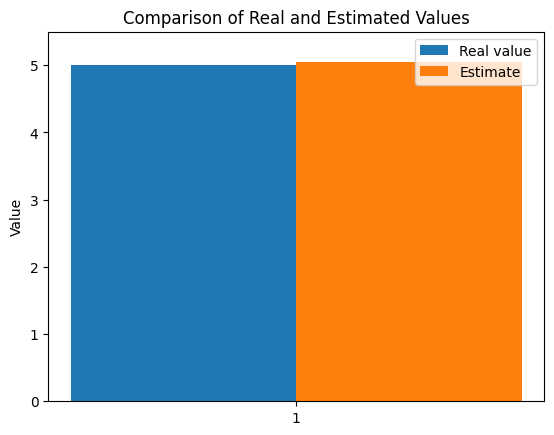

The function param_inverse took 232.519516 seconds.
| 2         | -0.0084   | 33.12     | 0.734     | 1.174     | 0.4665    |
Sampling 2 chains in parallel


2024-08-22 04:57:22,386	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  5.054  0.015   5.027    5.083      0.001    0.001     187.0     140.0   

    r_hat  
x0   1.01  
Estimated values are [5.054]
The difference between estimated values [0.054]



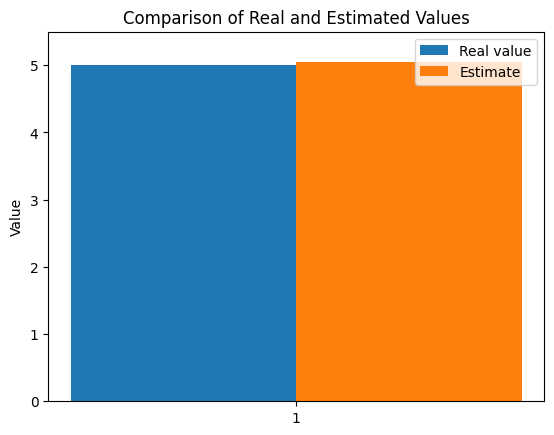

The function param_inverse took 219.863623 seconds.
| 3         | -0.0108   | 42.02     | 1.562     | 1.062     | 0.4925    |
Sampling 2 chains in parallel


2024-08-22 05:01:00,755	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  5.019  0.018   4.984    5.047      0.001    0.001     231.0     248.0   

    r_hat  
x0   1.02  
Estimated values are [5.019]
The difference between estimated values [0.019]



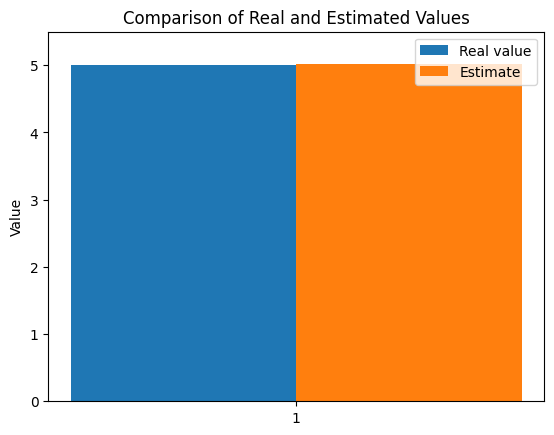

The function param_inverse took 242.548992 seconds.
| 4         | -0.0038   | 46.65     | 0.8185    | 1.545     | 0.2959    |
Sampling 2 chains in parallel


2024-08-22 05:05:07,294	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


    mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  5.02  0.017   4.993    5.053      0.001    0.001     168.0     228.0   

    r_hat  
x0    1.0  
Estimated values are [5.02]
The difference between estimated values [0.02]



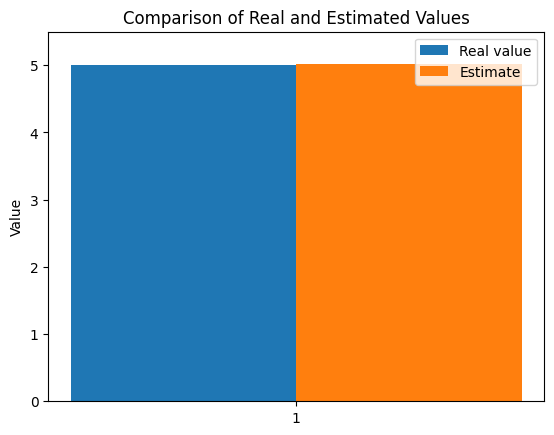

The function param_inverse took 230.079296 seconds.
| 5         | -0.004    | 46.68     | 0.8458    | 1.573     | 0.3236    |
Sampling 2 chains in parallel


2024-08-22 05:08:43,325	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  5.063  0.011   5.044    5.084      0.001      0.0     323.0     252.0   

    r_hat  
x0    1.0  
Estimated values are [5.063]
The difference between estimated values [0.063]



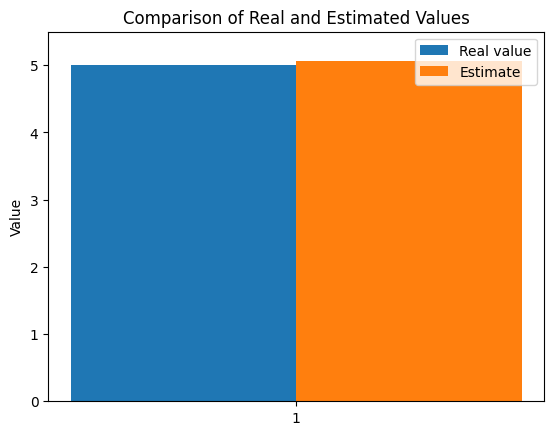

The function param_inverse took 209.100010 seconds.
| 6         | -0.0126   | 45.52     | 0.5       | 1.0       | 0.25      |
Sampling 2 chains in parallel


2024-08-22 05:12:26,818	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  5.066  0.017   5.038    5.101      0.001    0.001     285.0     307.0   

    r_hat  
x0   1.01  
Estimated values are [5.066]
The difference between estimated values [0.066]



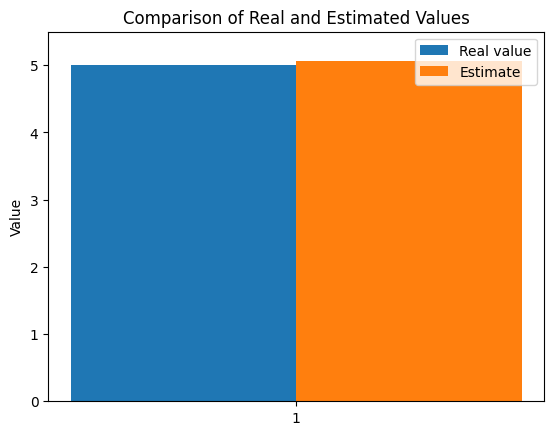

The function param_inverse took 224.164215 seconds.
| 7         | -0.0132   | 47.06     | 0.5       | 1.244     | 0.25      |
Sampling 2 chains in parallel


2024-08-22 05:16:06,482	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean    sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  5.047  0.06   4.932    5.149      0.003    0.002     316.0     253.0   

    r_hat  
x0   1.01  
Estimated values are [5.047]
The difference between estimated values [0.047]



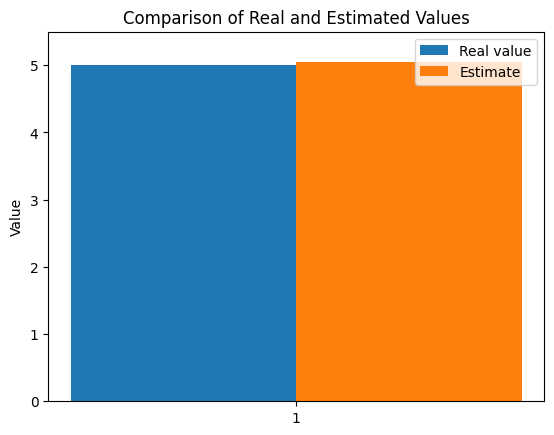

The function param_inverse took 217.811836 seconds.
| 8         | -0.0094   | 40.41     | 1.329     | 3.993     | 0.3336    |
Sampling 2 chains in parallel


2024-08-22 05:19:52,627	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


    mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  5.02  0.019   4.987    5.055      0.001    0.001     204.0     269.0   

    r_hat  
x0   1.01  
Estimated values are [5.02]
The difference between estimated values [0.02]



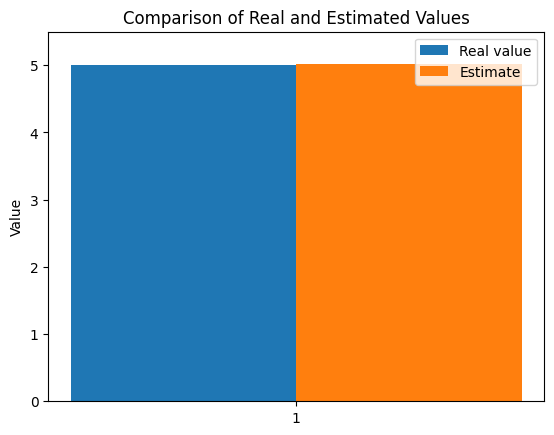

The function param_inverse took 228.778529 seconds.
| 9         | -0.004    | 46.43     | 0.9289    | 1.656     | 0.2553    |
Sampling 2 chains in parallel


2024-08-22 05:23:24,102	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  5.073  0.023   5.035    5.117      0.001    0.001     247.0     221.0   

    r_hat  
x0    1.0  
Estimated values are [5.073]
The difference between estimated values [0.073]



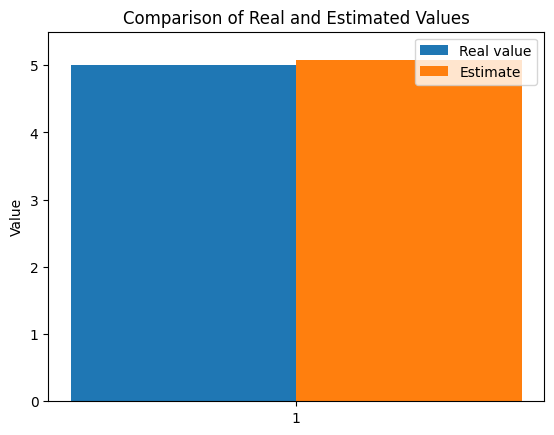

The function param_inverse took 210.527614 seconds.
| 10        | -0.0146   | 48.74     | 1.626     | 1.869     | 0.4675    |
Sampling 2 chains in parallel


2024-08-22 05:27:07,141	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  5.016  0.021   4.976    5.052      0.001    0.001     359.0     349.0   

    r_hat  
x0    1.0  
Estimated values are [5.016]
The difference between estimated values [0.016]



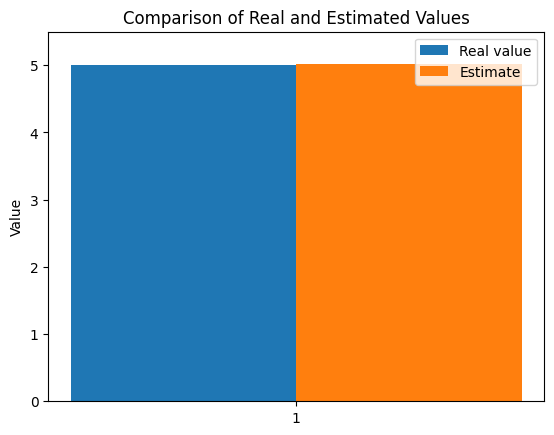

The function param_inverse took 224.187879 seconds.
| 11        | -0.0032   | 46.47     | 0.552     | 1.858     | 0.3486    |
Sampling 2 chains in parallel


2024-08-22 05:30:50,148	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  5.058  0.045   4.978    5.147      0.003    0.002     228.0     334.0   

    r_hat  
x0   1.01  
Estimated values are [5.058]
The difference between estimated values [0.058]



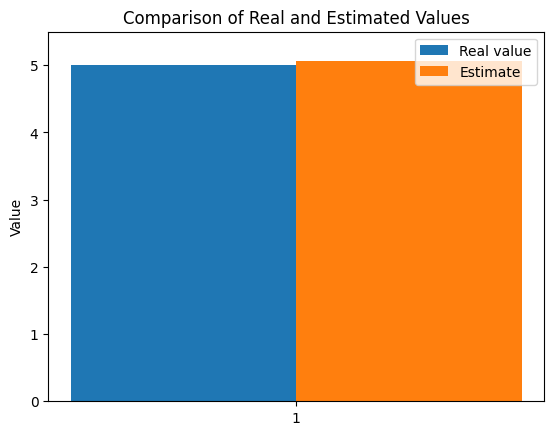

The function param_inverse took 195.130691 seconds.
| 12        | -0.0116   | 32.72     | 0.632     | 2.596     | 0.2777    |
Sampling 2 chains in parallel


2024-08-22 05:34:05,178	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  5.017  0.025   4.968    5.061      0.002    0.001     289.0     300.0   

    r_hat  
x0   1.01  
Estimated values are [5.017]
The difference between estimated values [0.017]



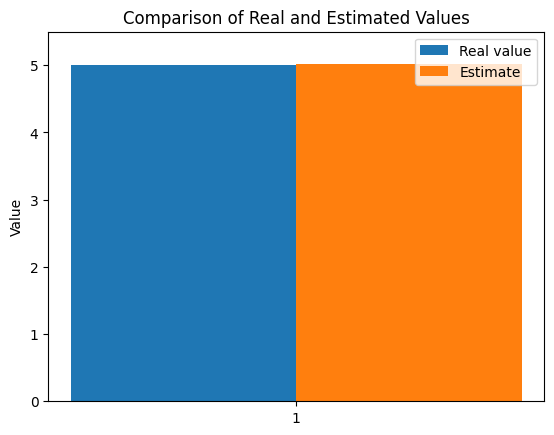

The function param_inverse took 220.673827 seconds.
| 13        | -0.0034   | 46.63     | 0.7874    | 2.279     | 0.25      |
Sampling 2 chains in parallel


2024-08-22 05:37:48,193	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  5.054  0.049   4.976    5.151      0.003    0.002     299.0     337.0   

    r_hat  
x0   1.01  
Estimated values are [5.054]
The difference between estimated values [0.054]



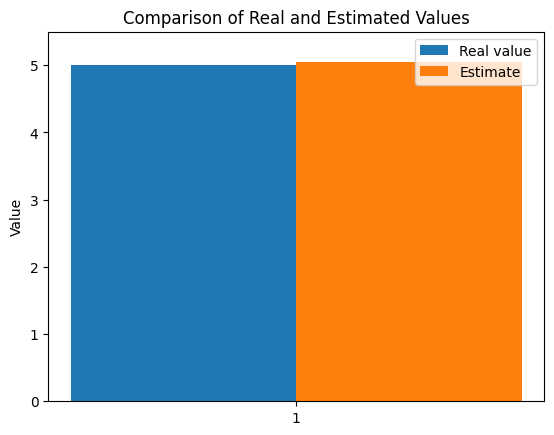

The function param_inverse took 223.434203 seconds.
| 14        | -0.0108   | 38.1      | 0.734     | 3.428     | 0.2958    |
Sampling 2 chains in parallel


2024-08-22 05:41:27,116	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  5.017  0.029   4.964    5.068      0.002    0.001     300.0     154.0   

    r_hat  
x0   1.01  
Estimated values are [5.017]
The difference between estimated values [0.017]



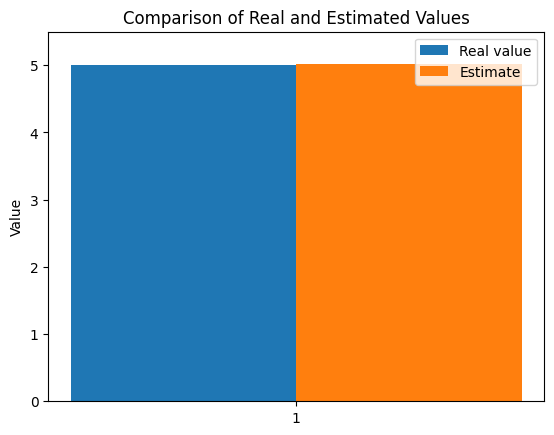

The function param_inverse took 218.028681 seconds.
| 15        | -0.0034   | 46.14     | 0.5       | 2.422     | 0.25      |
Sampling 2 chains in parallel


2024-08-22 05:45:09,474	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  5.012  0.036   4.938    5.072      0.002    0.001     307.0     321.0   

    r_hat  
x0   1.02  
Estimated values are [5.012]
The difference between estimated values [0.012]



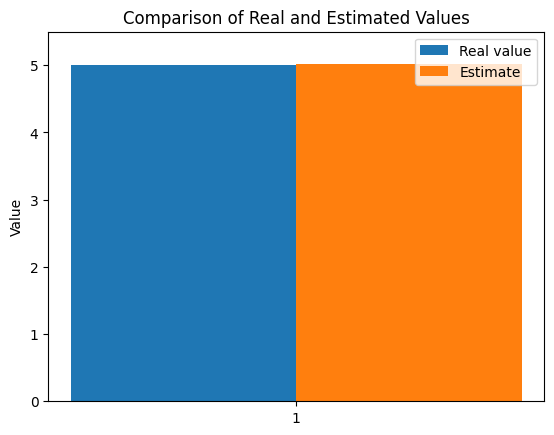

The function param_inverse took 222.640011 seconds.
| 16        | -0.0024   | 46.58     | 0.5       | 2.875     | 0.5       |
Sampling 2 chains in parallel


2024-08-22 05:48:54,129	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  5.018  0.034   4.962    5.088      0.002    0.002     235.0     135.0   

    r_hat  
x0   1.02  
Estimated values are [5.018]
The difference between estimated values [0.018]



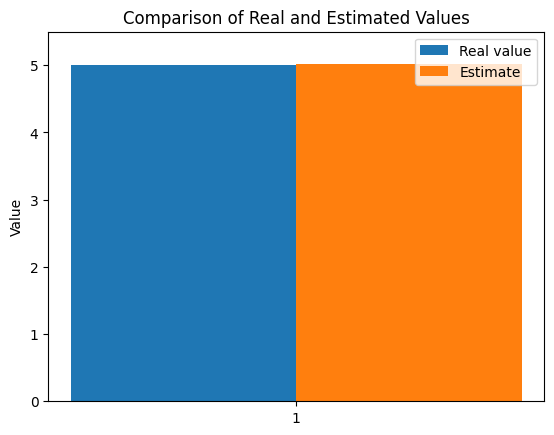

The function param_inverse took 225.441230 seconds.
| 17        | -0.0036   | 46.21     | 1.065     | 2.985     | 0.5       |
Sampling 2 chains in parallel


2024-08-22 05:52:40,905	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  5.014  0.042   4.945    5.108      0.002    0.002     326.0     214.0   

    r_hat  
x0   1.02  
Estimated values are [5.014]
The difference between estimated values [0.014]



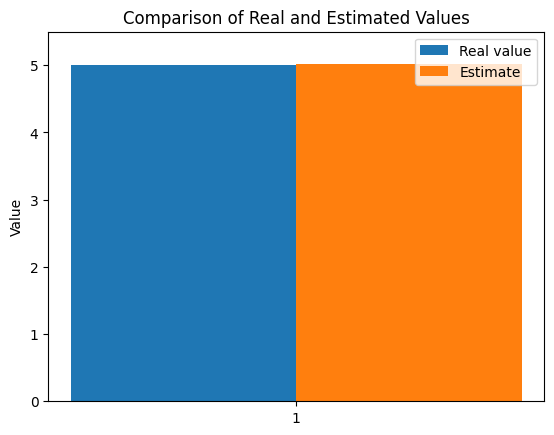

The function param_inverse took 227.056503 seconds.
| 18        | -0.0028   | 46.19     | 0.5       | 3.497     | 0.25      |
Sampling 2 chains in parallel


2024-08-22 05:56:25,607	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  5.021  0.046   4.927    5.098      0.003    0.002     265.0     246.0   

    r_hat  
x0   1.01  
Estimated values are [5.021]
The difference between estimated values [0.021]



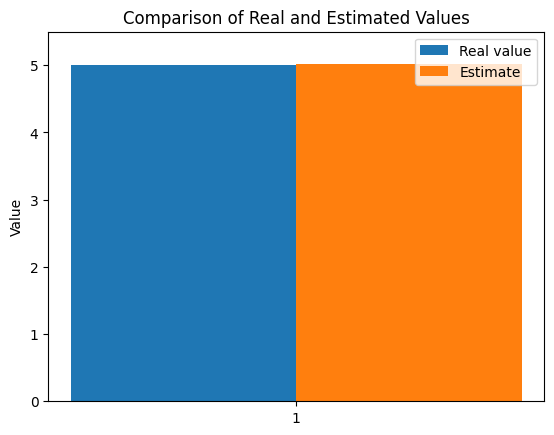

The function param_inverse took 224.496441 seconds.
| 19        | -0.0042   | 46.96     | 0.8628    | 3.512     | 0.25      |


In [13]:
mean_prior = np.array([2.5])
cov_prior = np.diag([1.])

sigma_noise_bounds = (0.25,0.5)
n_data_bounds = (30,50)
parameters = np.array([5.])
sigma_bounds = (1.,4.)
rwmh_scaling_bounds = (0.5,2.)
rwmh_cov = 1.
rwmh_adaptive = True
iterations = 2000
burnin = 1000
n_chains = 2
algo = "MH"

module_directory = os.path.abspath(os.path.join('..', 'utils'))

# Add the 'utils' directory containing Structure.py to the PYTHONPATH
os.environ['PYTHONPATH'] = module_directory
sys.path.append(module_directory)



params_MF= HPO_tinyDA(datahf=x_HF, 
                        mean_prior=mean_prior, 
                        cov_prior=cov_prior, 
                        Yhf=y_HF, 
                        sigma_noise=sigma_noise_bounds, 
                        n_data=n_data_bounds,
                        domain=(0.,8.),
                        parameters=parameters, 
                        sigma=sigma_bounds,
                        rwmh_scaling=rwmh_scaling_bounds, 
                        rwmh_cov=rwmh_cov, 
                        rwmh_adaptive=rwmh_adaptive, 
                        iterations=iterations, 
                        burnin=burnin, 
                        n_chains= n_chains, 
                        final_model=final_model_trained,
                        levels=1, 
                        algo=algo, 
                        force_sequential=False,
                        init_points=4,
                        n_iter=15)






|   iter    |  target   |  n_data   |   sigma   | sigma_... |
-------------------------------------------------------------
Sampling 2 chains in parallel


2024-08-22 15:23:53,631	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  5.047  0.072   4.929    5.203      0.004    0.003     366.0     347.0   

    r_hat  
x0   1.01  
Estimated values are [5.047]
The difference between estimated values [0.047]



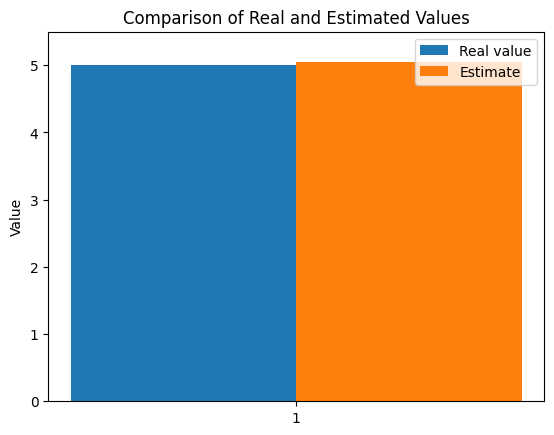

The function param_inverse took 282.264491 seconds.
| 1         | -0.0094   | 37.49     | 3.852     | 0.433     |
Sampling 2 chains in parallel


2024-08-22 15:28:49,830	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


(RemoteChain pid=94576) c:\Users\Giacomo\miniconda3\Lib\site-packages\tinyDA\proposal.py:236: RuntimeWarning: overflow encountered in exp
(RemoteChain pid=94576)   return np.exp(proposal_link.posterior - previous_link.posterior)
(RemoteChain pid=108260) c:\Users\Giacomo\miniconda3\Lib\site-packages\tinyDA\proposal.py:236: RuntimeWarning: overflow encountered in exp
(RemoteChain pid=108260)   return np.exp(proposal_link.posterior - previous_link.posterior)
(RemoteChain pid=83220) c:\Users\Giacomo\miniconda3\Lib\site-packages\tinyDA\proposal.py:236: RuntimeWarning: overflow encountered in exp
(RemoteChain pid=83220)   return np.exp(proposal_link.posterior - previous_link.posterior)
(RemoteChain pid=4500) c:\Users\Giacomo\miniconda3\Lib\site-packages\tinyDA\proposal.py:236: RuntimeWarning: overflow encountered in exp
(RemoteChain pid=4500)   return np.exp(proposal_link.posterior - previous_link.posterior)
(RemoteChain pid=47228) c:\Users\Giacomo\miniconda3\Lib\site-packages\tinyDA\proposa

     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  5.057  0.018   5.025    5.091      0.001    0.001     362.0     330.0   

    r_hat  
x0   1.01  
Estimated values are [5.057]
The difference between estimated values [0.057]



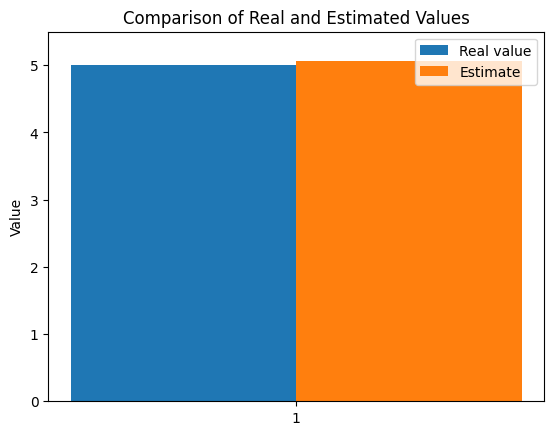

The function param_inverse took 307.909168 seconds.
| 2         | -0.0114   | 41.97     | 1.468     | 0.289     |
Sampling 2 chains in parallel


2024-08-22 15:33:57,561	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  5.024  0.062   4.902    5.128      0.003    0.002     480.0     415.0   

    r_hat  
x0   1.01  
Estimated values are [5.024]
The difference between estimated values [0.024]



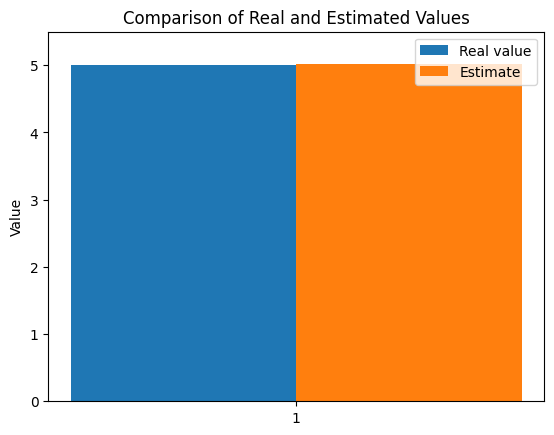

The function param_inverse took 300.790691 seconds.
| 3         | -0.0048   | 31.16     | 3.599     | 0.4003    |
Sampling 2 chains in parallel


2024-08-22 15:39:06,224	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  5.057  0.017   5.024    5.086      0.001    0.001     334.0     292.0   

    r_hat  
x0    1.0  
Estimated values are [5.057]
The difference between estimated values [0.057]



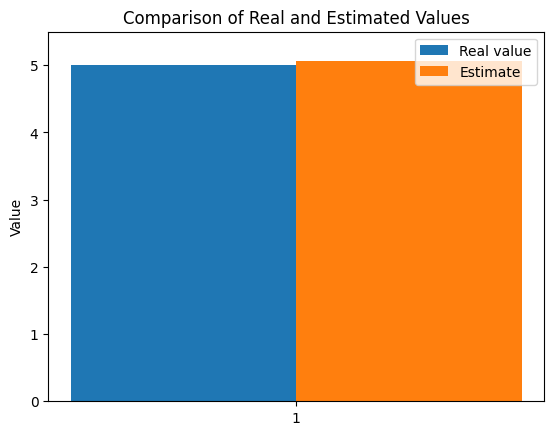

The function param_inverse took 289.612043 seconds.
| 4         | -0.0114   | 44.16     | 1.062     | 0.4925    |
Sampling 2 chains in parallel


2024-08-22 15:43:45,445	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  5.061  0.014   5.036    5.086      0.001    0.001     310.0     336.0   

    r_hat  
x0   1.02  
Estimated values are [5.061]
The difference between estimated values [0.061]



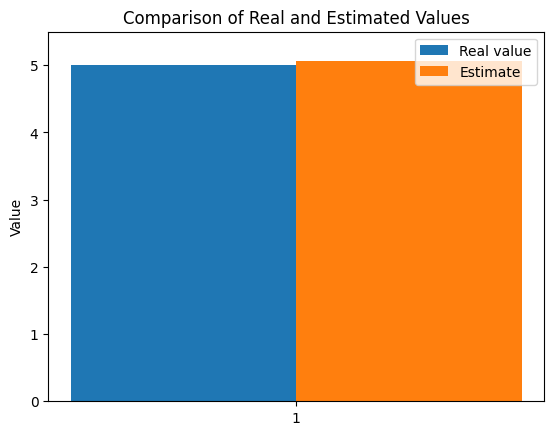

The function param_inverse took 227.065330 seconds.
| 5         | -0.0122   | 30.0      | 1.0       | 0.25      |
Sampling 2 chains in parallel


2024-08-22 15:47:26,415	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  5.031  0.068   4.891    5.145      0.003    0.002     408.0     305.0   

    r_hat  
x0   1.01  
Estimated values are [5.031]
The difference between estimated values [0.031]



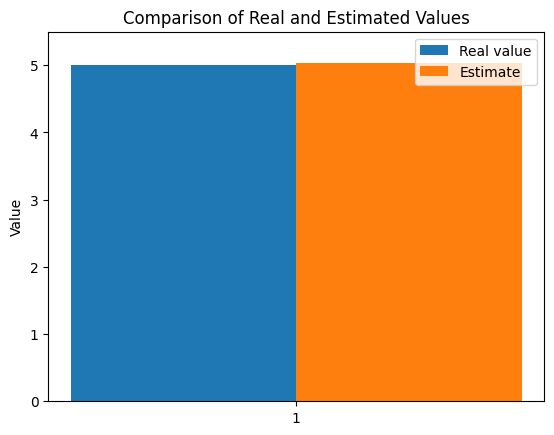

The function param_inverse took 221.572164 seconds.
| 6         | -0.0062   | 31.58     | 3.918     | 0.4849    |
Sampling 2 chains in parallel


2024-08-22 15:51:04,979	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  5.041  0.057   4.951    5.149      0.003    0.002     390.0     365.0   

    r_hat  
x0    1.0  
Estimated values are [5.041]
The difference between estimated values [0.041]



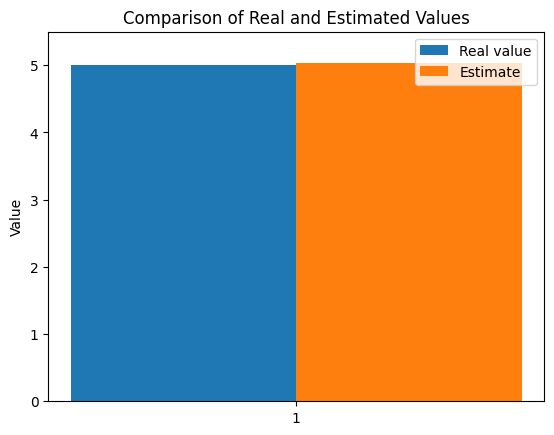

The function param_inverse took 231.557869 seconds.
| 7         | -0.0082   | 30.18     | 4.0       | 0.3113    |
Sampling 2 chains in parallel


2024-08-22 15:55:02,648	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  5.035  0.052   4.938    5.126      0.003    0.002     401.0     436.0   

    r_hat  
x0    1.0  
Estimated values are [5.035]
The difference between estimated values [0.035]



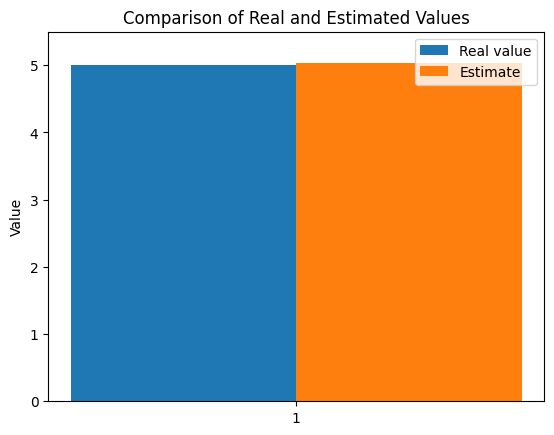

The function param_inverse took 234.271995 seconds.
| 8         | -0.007    | 31.59     | 2.862     | 0.25      |
Sampling 2 chains in parallel


2024-08-22 15:58:54,245	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  5.061  0.039   4.988    5.136      0.002    0.002     258.0     244.0   

    r_hat  
x0   1.01  
Estimated values are [5.061]
The difference between estimated values [0.061]



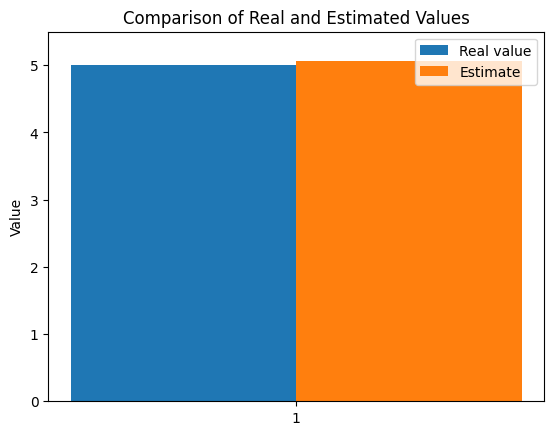

The function param_inverse took 224.207896 seconds.
| 9         | -0.0122   | 30.63     | 2.981     | 0.5       |
Sampling 2 chains in parallel


2024-08-22 16:02:39,118	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  5.046  0.057   4.937     5.15      0.003    0.002     407.0     391.0   

    r_hat  
x0    1.0  
Estimated values are [5.046]
The difference between estimated values [0.046]



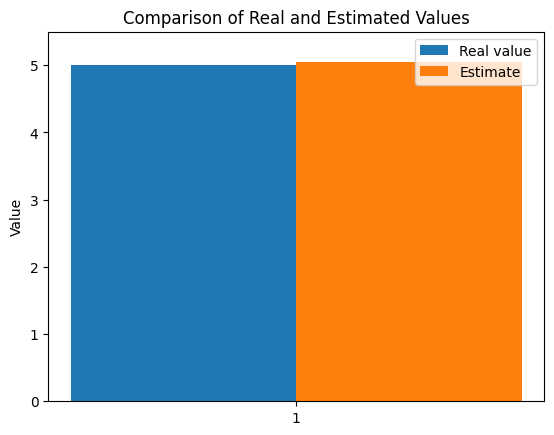

The function param_inverse took 227.037396 seconds.
| 10        | -0.0092   | 31.16     | 3.633     | 0.3883    |
Sampling 2 chains in parallel


2024-08-22 16:06:23,398	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  5.061  0.015   5.032    5.084      0.001      0.0     476.0     403.0   

    r_hat  
x0    1.0  
Estimated values are [5.061]
The difference between estimated values [0.061]



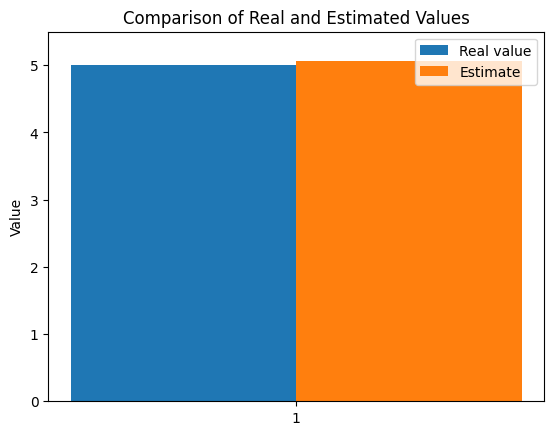

The function param_inverse took 237.519117 seconds.
| 11        | -0.0122   | 45.98     | 1.282     | 0.4255    |
Sampling 2 chains in parallel


2024-08-22 16:10:24,747	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  5.029  0.065   4.913     5.16      0.004    0.003     330.0     361.0   

    r_hat  
x0   1.02  
Estimated values are [5.029]
The difference between estimated values [0.029]



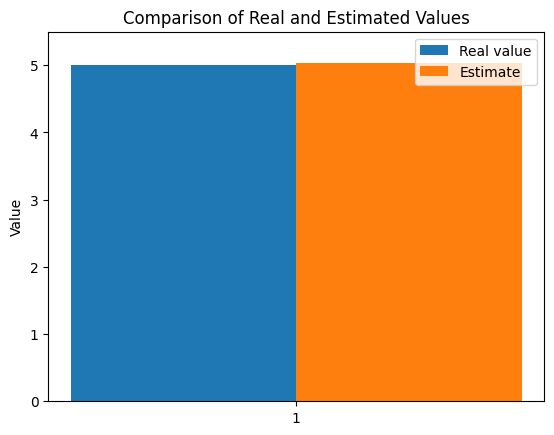

The function param_inverse took 255.841431 seconds.
| 12        | -0.0058   | 31.16     | 3.601     | 0.4026    |
Sampling 2 chains in parallel


2024-08-22 16:14:34,657	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  5.053  0.053   4.958    5.154      0.003    0.002     343.0     412.0   

    r_hat  
x0   1.01  
Estimated values are [5.053]
The difference between estimated values [0.053]



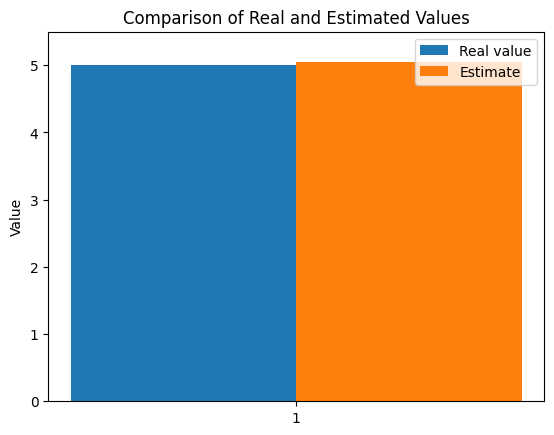

The function param_inverse took 247.459169 seconds.
| 13        | -0.0106   | 32.55     | 2.854     | 0.3447    |
Sampling 2 chains in parallel


2024-08-22 16:19:01,654	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  5.011  0.063    4.91    5.141      0.003    0.002     407.0     388.0   

    r_hat  
x0   1.01  
Estimated values are [5.011]
The difference between estimated values [0.011]



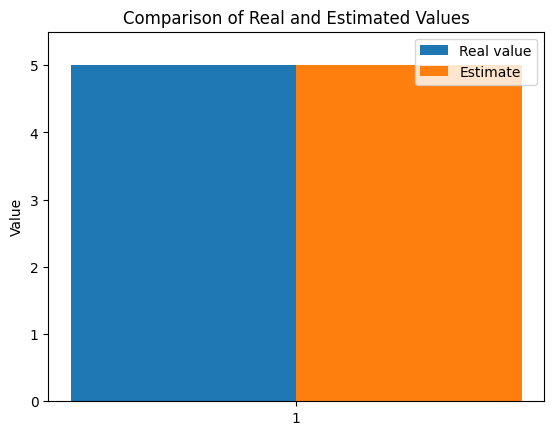

The function param_inverse took 283.441614 seconds.
| 14        | -0.0022   | 31.16     | 3.587     | 0.4026    |
Sampling 2 chains in parallel


2024-08-22 16:23:40,107	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  5.044  0.026     5.0    5.088      0.001    0.001     398.0     349.0   

    r_hat  
x0   1.02  
Estimated values are [5.044]
The difference between estimated values [0.044]



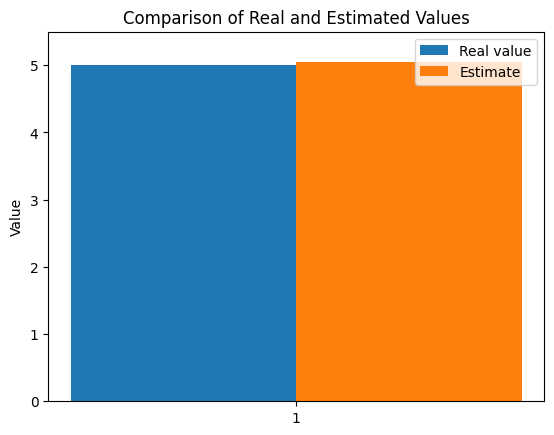

The function param_inverse took 261.852158 seconds.
| 15        | -0.0088   | 33.53     | 1.177     | 0.4233    |
Sampling 2 chains in parallel


2024-08-22 16:27:53,754	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  5.038  0.057   4.921    5.144      0.003    0.002     374.0     382.0   

    r_hat  
x0   1.01  
Estimated values are [5.038]
The difference between estimated values [0.038]



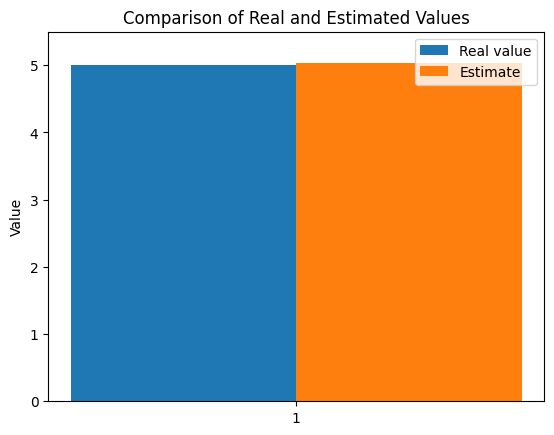

The function param_inverse took 224.643724 seconds.
| 16        | -0.0076   | 31.15     | 3.577     | 0.3894    |


In [12]:
mean_prior = np.array([2.5])
cov_prior = np.diag([1.])

sigma_noise_bounds = (0.25,0.5)
n_data_bounds = (30,50)
parameters = np.array([5.])
sigma_bounds = (1.,4.)
rwmh_scaling_bounds = (0.5,2.)
rwmh_cov = 1
rwmh_adaptive = True
iterations = 2000
burnin = 1000
n_chains = 2
algo = "AM"

module_directory = os.path.abspath(os.path.join('..', 'utils'))

# Add the 'utils' directory containing Structure.py to the PYTHONPATH
os.environ['PYTHONPATH'] = module_directory
sys.path.append(module_directory)





params_MF= HPO_tinyDA(datahf=x_HF, 
                        mean_prior=mean_prior, 
                        cov_prior=cov_prior, 
                        Yhf=y_HF, 
                        sigma_noise=sigma_noise_bounds, 
                        n_data=n_data_bounds,
                        domain=(0.,8.),
                        parameters=parameters, 
                        sigma=sigma_bounds,
                        rwmh_scaling=rwmh_scaling_bounds, 
                        rwmh_cov=rwmh_cov, 
                        rwmh_adaptive=rwmh_adaptive, 
                        iterations=iterations, 
                        burnin=burnin, 
                        n_chains= n_chains, 
                        final_model=final_model_trained,
                        levels=1, 
                        algo=algo, 
                        force_sequential=False,
                        init_points=4,
                        n_iter=12)


|   iter    |  target   |  n_data   | rwmh_s... | sigma_... |
-------------------------------------------------------------
Sampling 2 chains in parallel


2024-08-22 12:08:33,914	INFO worker.py:1788 -- Started a local Ray instance.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  5.277  0.228   5.049    5.506      0.161    0.136       3.0       3.0   

    r_hat  
x0   2.36  
Estimated values are [5.277]
The difference between estimated values [0.277]



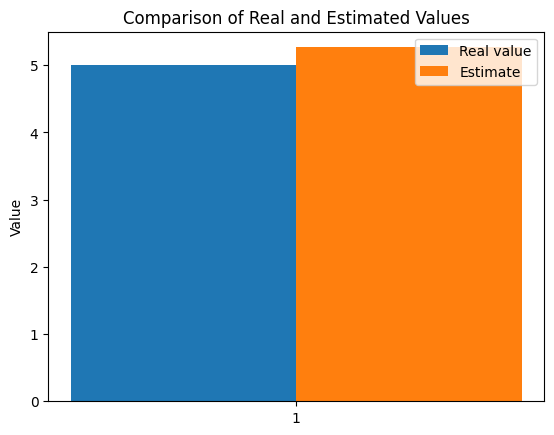

The function param_inverse took 484.998120 seconds.
| 1         | -0.0554   | 37.49     | 1.926     | 0.433     |
Sampling 2 chains in parallel


2024-08-22 12:16:21,623	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


    mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  5.11  0.076    5.02    5.186      0.053    0.045       2.0      10.0   

    r_hat  
x0   3.36  
Estimated values are [5.11]
The difference between estimated values [0.11]



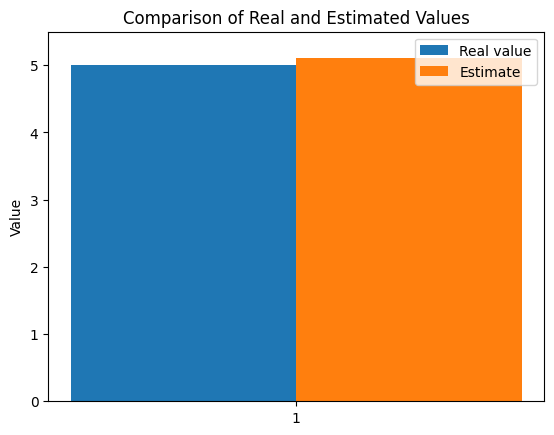

The function param_inverse took 473.858660 seconds.
| 2         | -0.022    | 41.97     | 0.734     | 0.289     |
Sampling 2 chains in parallel


2024-08-22 12:24:15,502	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  4.989  0.043   4.939    5.032       0.03    0.025       3.0       7.0   

    r_hat  
x0   2.17  
Estimated values are [4.989]
The difference between estimated values [0.011]



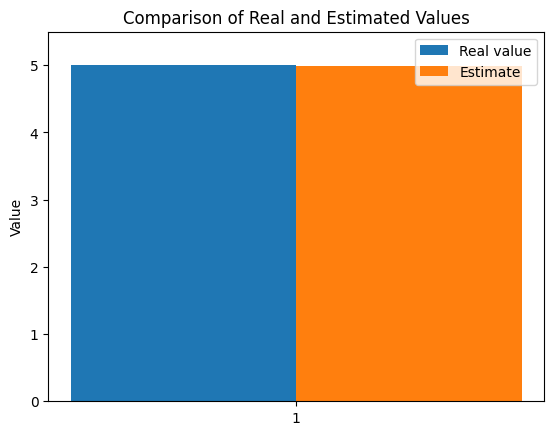

The function param_inverse took 442.591832 seconds.
| 3         | -0.0022   | 31.16     | 1.799     | 0.4003    |
Sampling 2 chains in parallel


2024-08-22 12:31:52,192	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  2.235  0.026   2.197    2.278      0.007    0.005      13.0      17.0   

    r_hat  
x0   1.14  
Estimated values are [2.235]
The difference between estimated values [2.765]



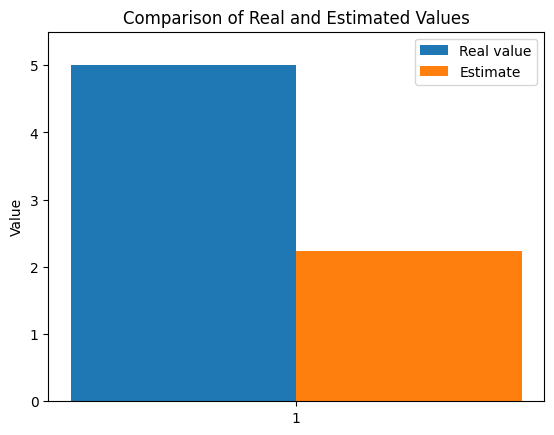

The function param_inverse took 462.250070 seconds.
| 4         | -0.553    | 44.16     | 0.5309    | 0.4925    |
Sampling 2 chains in parallel


2024-08-22 12:39:29,601	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  5.369  0.371   4.995    5.742      0.262    0.221       2.0       5.0   

    r_hat  
x0   2.64  
Estimated values are [5.369]
The difference between estimated values [0.369]



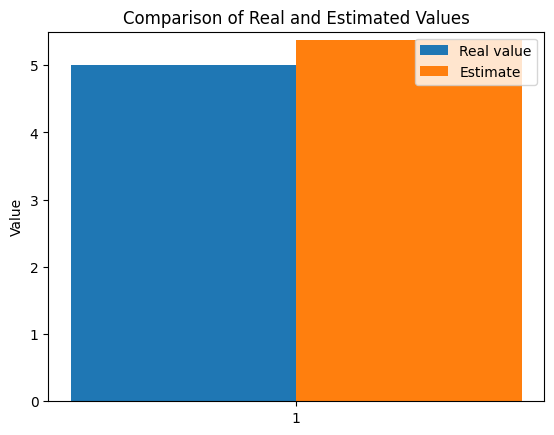

The function param_inverse took 456.080762 seconds.
| 5         | -0.0738   | 31.2      | 1.835     | 0.3289    |
Sampling 2 chains in parallel


2024-08-22 12:47:07,713	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  5.293  0.217   5.055    5.513      0.153    0.129       3.0      14.0   

    r_hat  
x0    2.2  
Estimated values are [5.293]
The difference between estimated values [0.293]



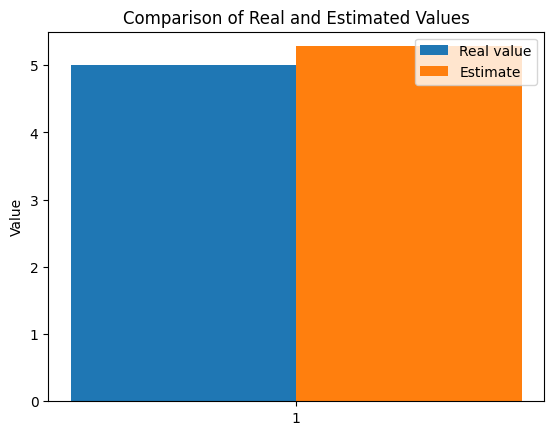

The function param_inverse took 458.570738 seconds.
| 6         | -0.0586   | 30.86     | 1.493     | 0.5       |
Sampling 2 chains in parallel


2024-08-22 12:54:47,508	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  5.063  0.023   5.035     5.09      0.006    0.004      16.0      11.0   

    r_hat  
x0   1.07  
Estimated values are [5.063]
The difference between estimated values [0.063]



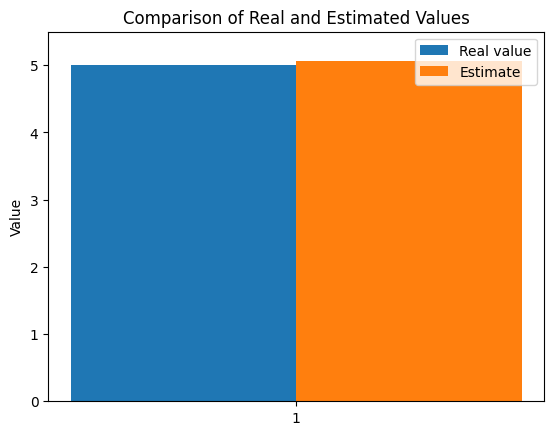

The function param_inverse took 459.158696 seconds.
| 7         | -0.0126   | 30.72     | 1.347     | 0.4381    |
Sampling 2 chains in parallel


2024-08-22 13:02:15,357	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  5.151  0.147   5.004    5.298      0.104    0.088       2.0       3.0   

    r_hat  
x0   4.68  
Estimated values are [5.151]
The difference between estimated values [0.151]



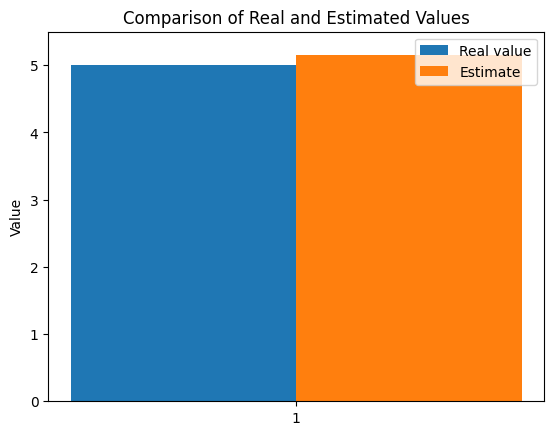

The function param_inverse took 556.931921 seconds.
| 8         | -0.0302   | 46.79     | 1.551     | 0.3023    |
Sampling 2 chains in parallel


2024-08-22 13:11:49,111	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  5.233  0.177   5.051    5.422      0.125    0.106       2.0      21.0   

    r_hat  
x0   2.78  
Estimated values are [5.233]
The difference between estimated values [0.233]



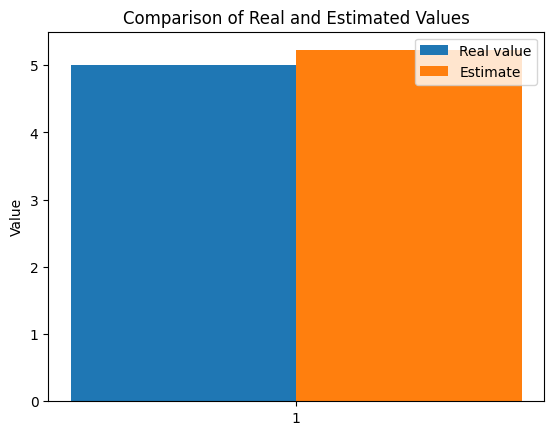

The function param_inverse took 532.132817 seconds.
| 9         | -0.0466   | 30.39     | 0.9829    | 0.25      |
Sampling 2 chains in parallel


2024-08-22 13:20:38,426	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  5.188  0.131   5.036    5.318      0.092    0.078       2.0       5.0   

    r_hat  
x0   2.67  
Estimated values are [5.188]
The difference between estimated values [0.188]



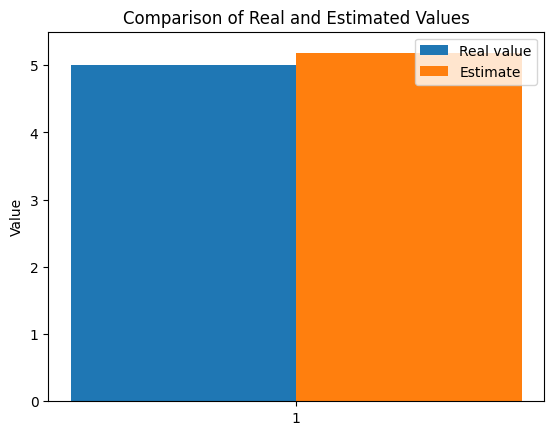

The function param_inverse took 531.718926 seconds.
| 10        | -0.0376   | 48.56     | 1.077     | 0.3467    |
Sampling 2 chains in parallel


2024-08-22 13:29:29,435	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean    sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  5.225  0.22   5.001    5.445      0.155    0.131       2.0       6.0   

    r_hat  
x0   2.77  
Estimated values are [5.225]
The difference between estimated values [0.225]



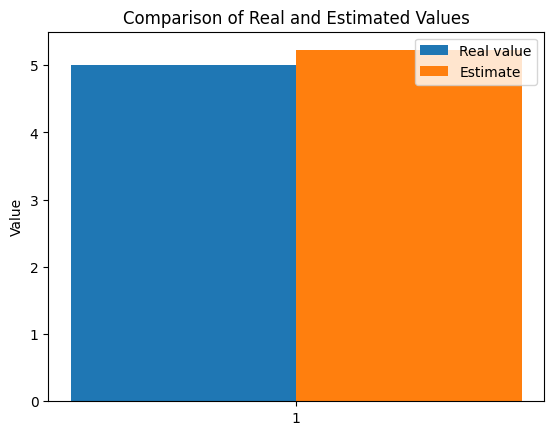

The function param_inverse took 513.014666 seconds.
| 11        | -0.045    | 31.4      | 1.435     | 0.5       |
Sampling 2 chains in parallel


2024-08-22 13:38:06,588	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  5.286  0.283   4.991    5.575      0.199    0.168       2.0      11.0   

    r_hat  
x0   2.92  
Estimated values are [5.286]
The difference between estimated values [0.286]



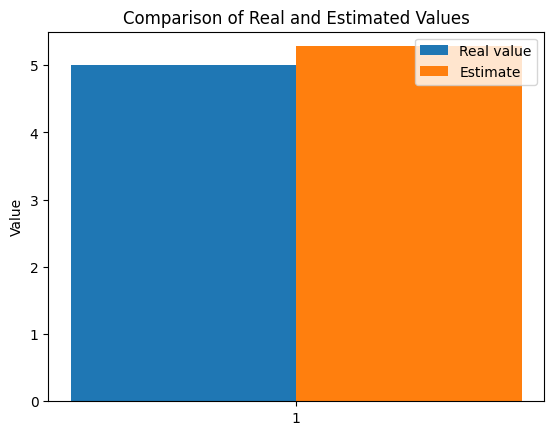

The function param_inverse took 537.671901 seconds.
| 12        | -0.0572   | 36.35     | 1.836     | 0.2841    |
Sampling 2 chains in parallel


2024-08-22 13:47:00,739	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean    sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  5.301  0.22   5.059    5.523      0.155    0.131       2.0       8.0   

    r_hat  
x0   2.66  
Estimated values are [5.301]
The difference between estimated values [0.301]



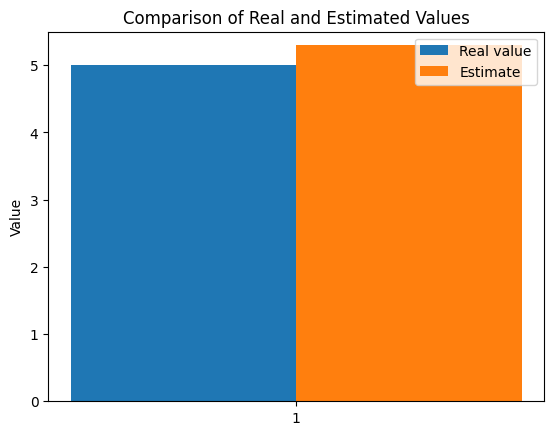

The function param_inverse took 506.160976 seconds.
| 13        | -0.0602   | 30.81     | 2.0       | 0.5       |
Sampling 2 chains in parallel


2024-08-22 13:55:26,120	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


    mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  5.05  0.025   5.007    5.085      0.017    0.014       2.0      10.0   

    r_hat  
x0   3.09  
Estimated values are [5.05]
The difference between estimated values [0.05]



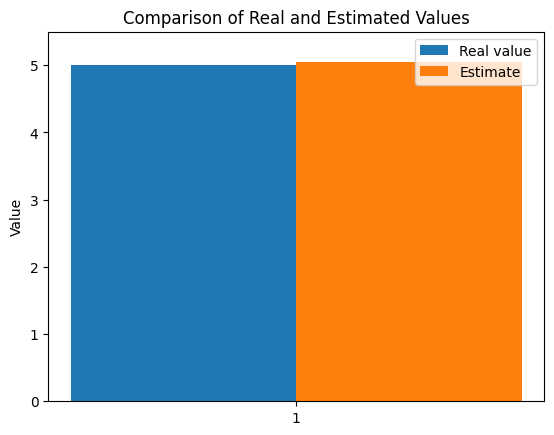

The function param_inverse took 513.996101 seconds.
| 14        | -0.01     | 30.95     | 0.971     | 0.25      |
Sampling 2 chains in parallel


2024-08-22 14:04:04,150	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  5.212  0.176   5.005    5.387      0.124    0.105       2.0      22.0   

    r_hat  
x0   2.49  
Estimated values are [5.212]
The difference between estimated values [0.212]



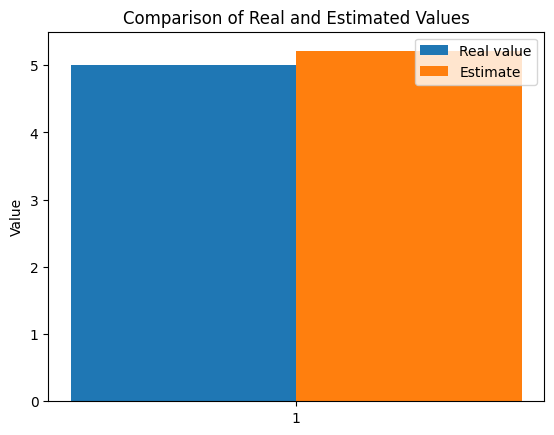

The function param_inverse took 523.723321 seconds.
| 15        | -0.0424   | 30.77     | 0.5841    | 0.5       |
Sampling 2 chains in parallel


2024-08-22 14:12:33,783	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  5.097  0.079   5.015     5.18      0.055    0.047       2.0       4.0   

    r_hat  
x0   2.81  
Estimated values are [5.097]
The difference between estimated values [0.097]



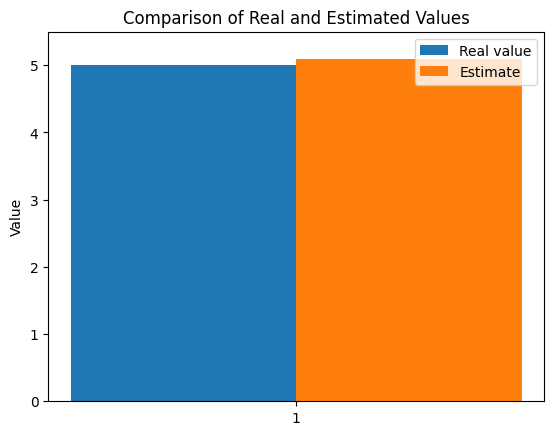

The function param_inverse took 486.604080 seconds.
| 16        | -0.0194   | 31.35     | 0.7463    | 0.5       |
Sampling 2 chains in parallel


2024-08-22 14:20:55,958	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  5.054  0.016   5.035    5.081      0.007    0.005      11.0       5.0   

    r_hat  
x0   1.17  
Estimated values are [5.054]
The difference between estimated values [0.054]



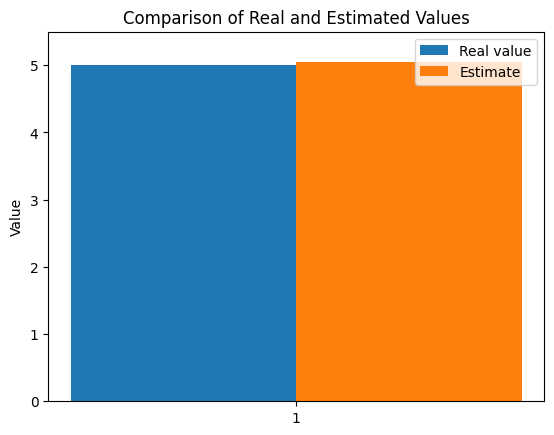

The function param_inverse took 500.482952 seconds.
| 17        | -0.0108   | 30.22     | 1.475     | 0.5       |
Sampling 2 chains in parallel


2024-08-22 14:29:04,171	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean    sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  5.553  0.47   5.072    6.023      0.331     0.28       3.0      15.0   

    r_hat  
x0   2.22  
Estimated values are [5.553]
The difference between estimated values [0.553]



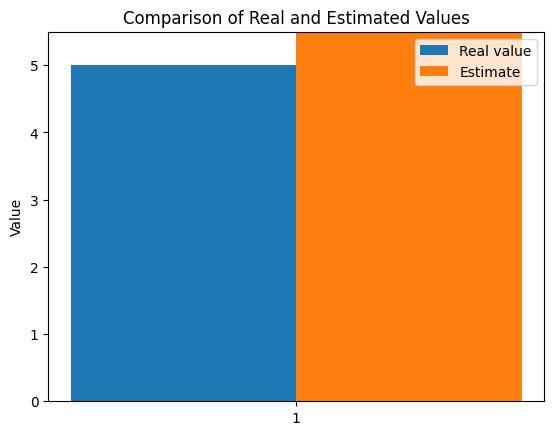

The function param_inverse took 491.765345 seconds.
| 18        | -0.1106   | 30.0      | 1.857     | 0.25      |
Sampling 2 chains in parallel


2024-08-22 14:37:26,633	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  4.994  0.049   4.944    5.046      0.034    0.029       3.0       2.0   

    r_hat  
x0   2.36  
Estimated values are [4.994]
The difference between estimated values [0.006]



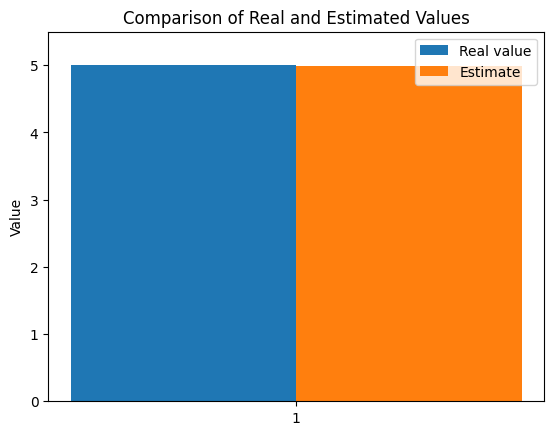

The function param_inverse took 504.118658 seconds.
| 19        | -0.0012   | 31.75     | 0.8945    | 0.25      |


In [11]:
mean_prior = np.array([2.5])
cov_prior = np.diag([1.])

sigma_noise_bounds = (0.25,0.5)
n_data_bounds = (30,50)
parameters = np.array([5.])
sigma_bounds = 2.#(1.,4.)
rwmh_scaling_bounds = (0.5,2.)
rwmh_cov = 1.
rwmh_adaptive = True
iterations = 2000
burnin = 1000
n_chains = 2
algo = "MH"

module_directory = os.path.abspath(os.path.join('..', 'utils'))

# Add the 'utils' directory containing Structure.py to the PYTHONPATH
os.environ['PYTHONPATH'] = module_directory
sys.path.append(module_directory)





params_MF= HPO_tinyDA(datahf=x_HF, 
                        mean_prior=mean_prior, 
                        cov_prior=cov_prior, 
                        Yhf=y_HF, 
                        sigma_noise=sigma_noise_bounds, 
                        n_data=n_data_bounds,
                        domain=(0.,8.),
                        parameters=parameters, 
                        sigma=sigma_bounds,
                        rwmh_scaling=rwmh_scaling_bounds, 
                        rwmh_cov=rwmh_cov, 
                        rwmh_adaptive=rwmh_adaptive, 
                        iterations=iterations, 
                        burnin=burnin, 
                        n_chains= n_chains, 
                        subsampling_rate=3,
                        final_model=final_model_trained,
                        levels=2, 
                        algo=algo, 
                        force_sequential=False, init_points=4,
                        n_iter=15)


Sampling 2 chains in parallel


2024-08-16 16:18:17,958	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.
c:\Users\Giacomo\miniconda3\Lib\site-packages\arviz\data\inference_data.py:157: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


Estimated values are [5.056]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  5.056  0.076   4.901    5.179      0.004    0.003     342.0     323.0   

    r_hat  
x0   1.01  


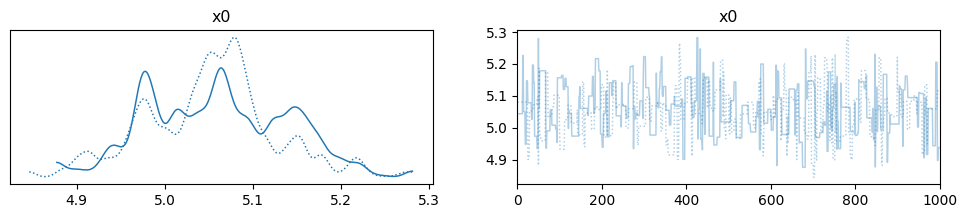

The difference between estimated values [0.056]



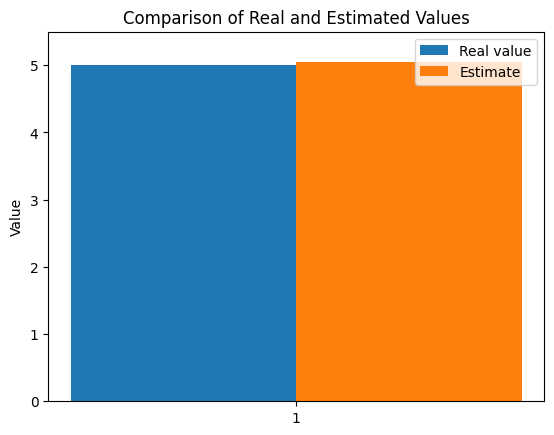

The function param_inverse took 383.364743 seconds.
Sampling 2 chains in parallel


2024-08-16 16:24:25,800	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


Estimated values are [5.053]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  5.053  0.079   4.928    5.219      0.004    0.003     445.0     378.0   

    r_hat  
x0   1.01  


c:\Users\Giacomo\miniconda3\Lib\site-packages\arviz\data\inference_data.py:157: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


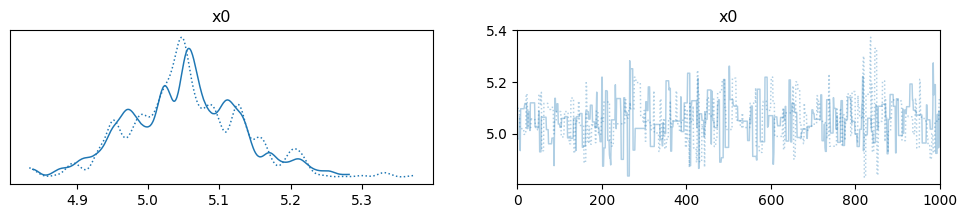

The difference between estimated values [0.053]



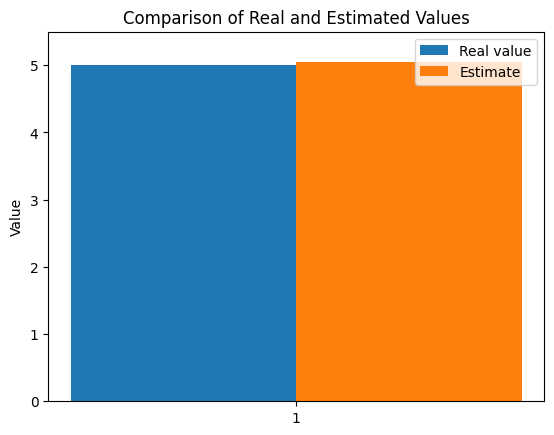

The function param_inverse took 375.776330 seconds.
Sampling 2 chains in parallel


2024-08-16 16:30:55,071	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


Estimated values are [5.056]
     mean    sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  5.056  0.08   4.927    5.204      0.005    0.004     249.0     339.0   

    r_hat  
x0   1.01  


c:\Users\Giacomo\miniconda3\Lib\site-packages\arviz\data\inference_data.py:157: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


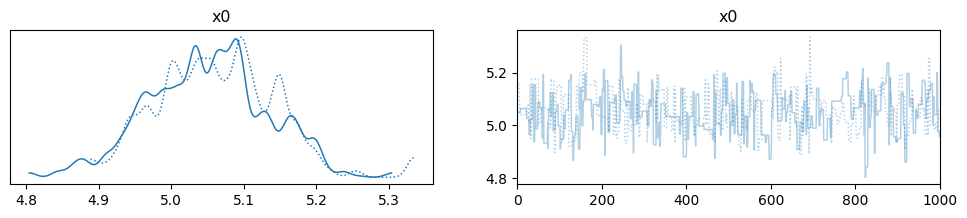

The difference between estimated values [0.056]



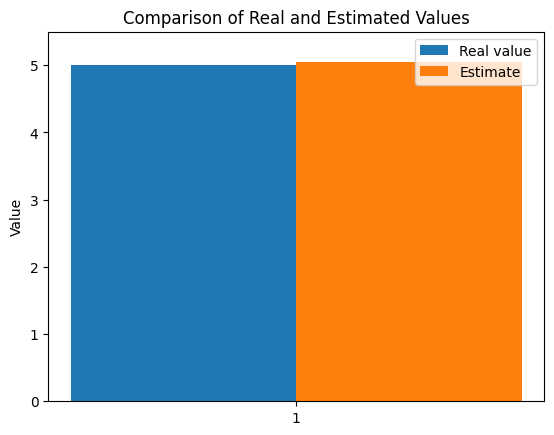

The function param_inverse took 374.539224 seconds.
Sampling 2 chains in parallel


2024-08-16 16:37:10,250	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


Estimated values are [5.047]
     mean    sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  5.047  0.04   4.974    5.122      0.003    0.002     163.0     216.0   

    r_hat  
x0   1.03  


c:\Users\Giacomo\miniconda3\Lib\site-packages\arviz\data\inference_data.py:157: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


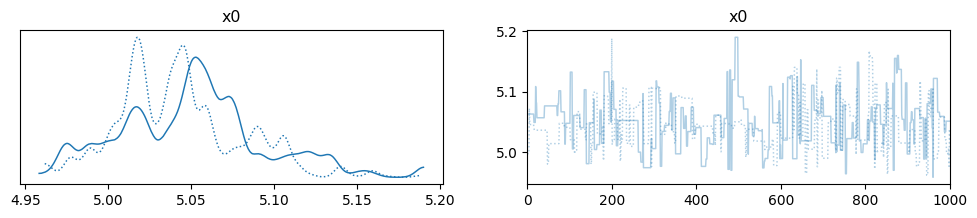

The difference between estimated values [0.047]



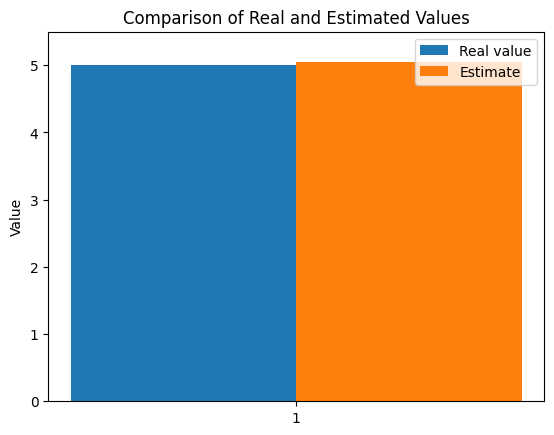

The function param_inverse took 381.299575 seconds.
Sampling 2 chains in parallel


2024-08-16 16:43:18,309	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


Estimated values are [5.055]
     mean    sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  5.055  0.04   4.989    5.132      0.002    0.002     282.0     273.0   

    r_hat  
x0    1.0  


c:\Users\Giacomo\miniconda3\Lib\site-packages\arviz\data\inference_data.py:157: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


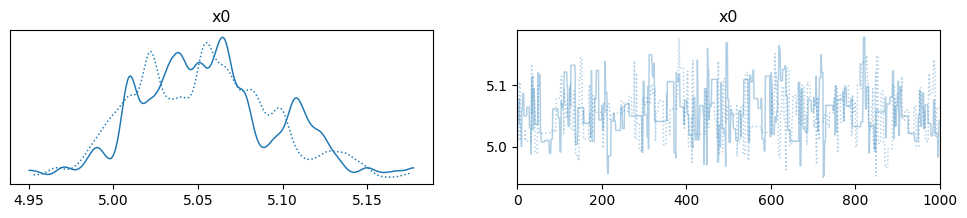

The difference between estimated values [0.055]



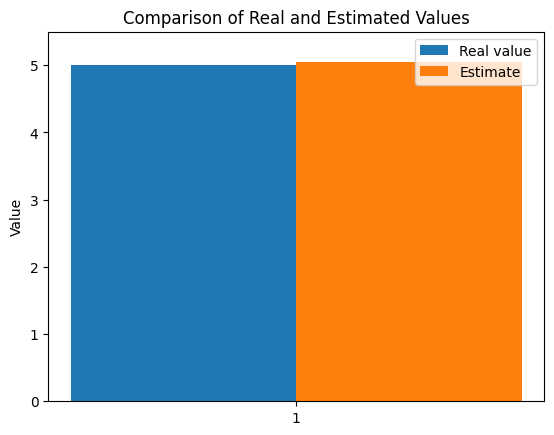

The function param_inverse took 367.622142 seconds.
Sampling 2 chains in parallel


2024-08-16 16:49:30,953	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


Estimated values are [5.053]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  5.053  0.042   4.979    5.129      0.003    0.002     234.0     244.0   

    r_hat  
x0   1.01  


c:\Users\Giacomo\miniconda3\Lib\site-packages\arviz\data\inference_data.py:157: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


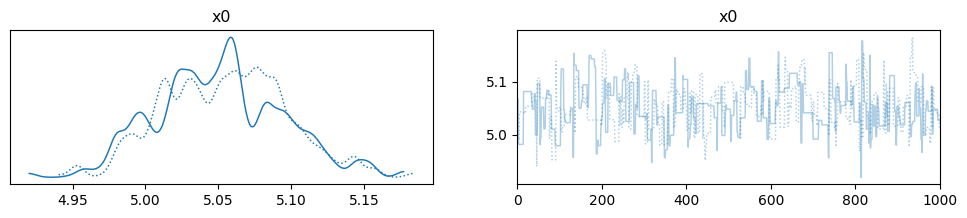

The difference between estimated values [0.053]



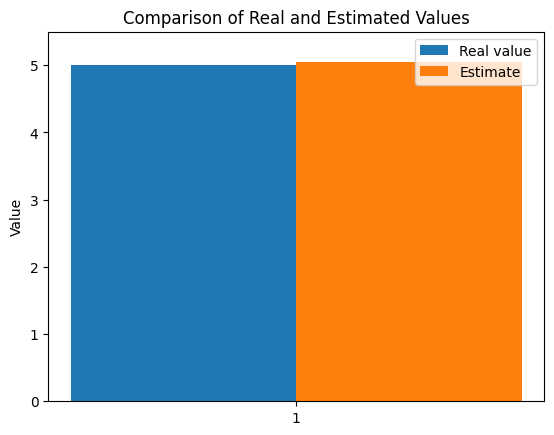

The function param_inverse took 387.969752 seconds.
Sampling 2 chains in parallel


2024-08-16 16:55:50,370	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.
c:\Users\Giacomo\miniconda3\Lib\site-packages\arviz\data\inference_data.py:157: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


Estimated values are [5.018]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  5.018  0.097   4.836    5.201      0.006    0.004     312.0     264.0   

    r_hat  
x0   1.01  


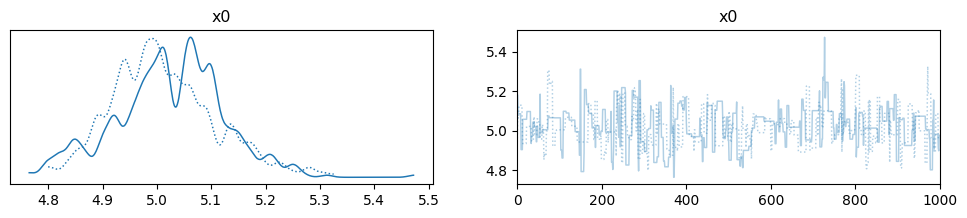

The difference between estimated values [0.018]



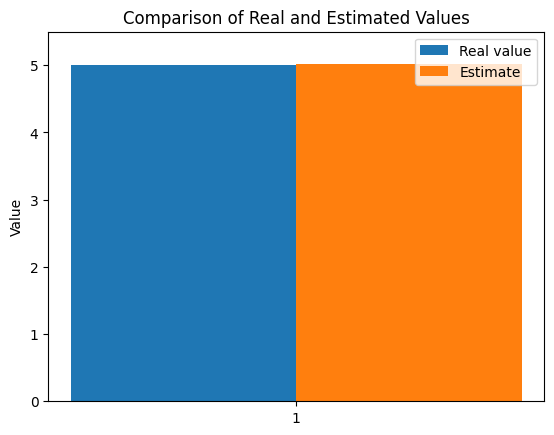

The function param_inverse took 377.628801 seconds.
Sampling 2 chains in parallel


2024-08-16 17:02:18,681	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


Estimated values are [5.008]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  5.008  0.092    4.85    5.188      0.006    0.004     221.0     296.0   

    r_hat  
x0   1.02  


c:\Users\Giacomo\miniconda3\Lib\site-packages\arviz\data\inference_data.py:157: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


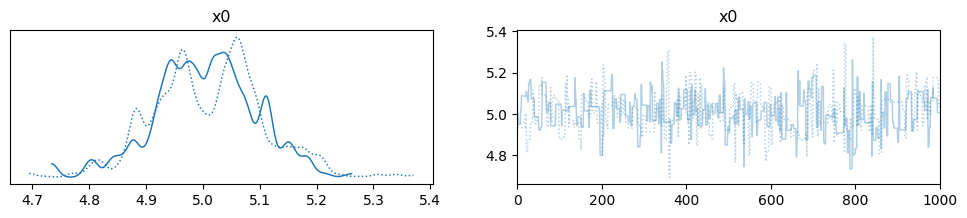

The difference between estimated values [0.008]



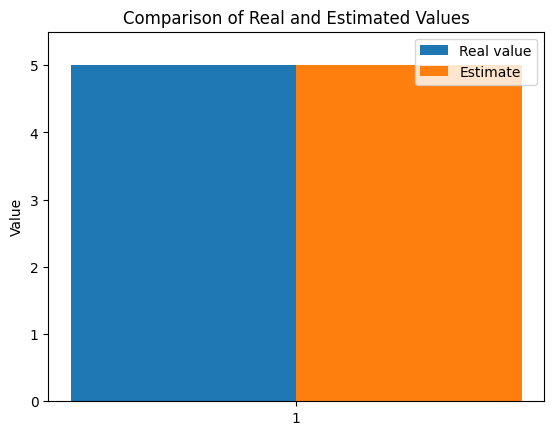

The function param_inverse took 380.430931 seconds.
Sampling 2 chains in parallel


2024-08-16 17:08:30,771	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


ActorDiedError: The actor died because of an error raised in its creation task, [36mray::RemoteChain.__init__()[39m (pid=1515784, ip=127.0.0.1, actor_id=d71ccf8cfeac029996b4c7f601000000, repr=<tinyDA.ray.RemoteChain object at 0x00000291FFA301D0>)
  File "python\ray\_raylet.pyx", line 1901, in ray._raylet.execute_task
  File "python\ray\_raylet.pyx", line 1842, in ray._raylet.execute_task.function_executor
  File "c:\Users\Giacomo\miniconda3\Lib\site-packages\ray\_private\function_manager.py", line 691, in actor_method_executor
    return method(__ray_actor, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Giacomo\miniconda3\Lib\site-packages\ray\util\tracing\tracing_helper.py", line 467, in _resume_span
    return method(self, *_args, **_kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Giacomo\miniconda3\Lib\site-packages\tinyDA\chain.py", line 70, in __init__
    self.chain.append(self.posterior.create_link(self.initial_parameters)

In [13]:
mean_prior = np.array([2.5])
cov_prior = np.diag([1.])

sigma_noise = [0.25,0.5]
n_data = [30,20,10]
parameters = np.array([5.])
sigma = np.array([ 4.,2.])
rwmh_scaling = np.array([ 2.,0.5,1.])
rwmh_cov = np.eye(1)
rwmh_adaptive = True
iterations = 2000
burnin = 1000
n_chains = 2
algo = "MH"

module_directory = os.path.abspath(os.path.join('..', 'utils'))

# Add the 'utils' directory containing Structure.py to the PYTHONPATH
os.environ['PYTHONPATH'] = module_directory
sys.path.append(module_directory)

estimateMF, errorMF, param_resultsMF= run_simulation(x_HF, mean_prior, cov_prior, y_HF, sigma_noise, n_data, parameters, sigma, rwmh_scaling, rwmh_cov, rwmh_adaptive, iterations, burnin, n_chains, final_model_trained,algo)


In [ ]:
cov_prior = np.diag([1.,1.,1.])


In [12]:
# Define inputs
mean_prior = np.array([7.])
cov_prior = np.diag([1.])
Yhf = y_HF
sd_noise = [0.1,0.05]
N = 300
burn_in = 200
number_chains = 2
algo = "MH"
x_real = np.array([5.])
proposal_sd = [4.,2.]
adapt = True
n_data = [50,30]


module_directory = os.path.abspath(os.path.join('..', 'utils'))

# Add the 'utils' directory containing Structure2.py to the PYTHONPATH
os.environ['PYTHONPATH'] = module_directory
sys.path.append(module_directory)

x_data=  np.linspace(0., 5., n_data[0]).reshape(-1, 1)  # Generate evaluation times
nearest_x, y_obs = process_data(x_HF, x_real, x_data, Yhf) 

# estimates = final_model.inverse_cuqi(
#     mean_prior=mean_prior,
#     x_real=x_real,
#     y_obs=y_obs,
#     N=N,
#     burn_in=burn_in,
#     cov_prior=cov_prior,
#     sd_noise=sd_noise,  
#     adapt=adapt,
#     scale=proposal_sd,
#     proposal_sd=proposal_sd,
#     number_chains=number_chains,
#     algo=algo,
#     x_data=x_data
# )
estimates=run_simulation_cuqi(x_HF,y_HF,
    mean_prior,
    x_real,
    N,
    burn_in,
    cov_prior,
    sd_noise,  
    adapt,
    
    proposal_sd,
    number_chains,
    algo,
    x_data,
    n_data,
    final_model,
    parallel=False
) 

ValueError: operands could not be broadcast together with shapes (50,3) (150,) 

In [ ]:
x_HF.shape

(5010, 2)

In [ ]:
mean=np.mean(x_HF)

In [ ]:
mean

4.0

In [ ]:
# Name of the folder
folder_name = "2_step_models_mu"
folder_path = os.path.join(os.getcwd(), folder_name)

# create the folder
if not os.path.exists(folder_path):
    os.makedirs(folder_path)
    print(f"Folder '{folder_name}' created.")
else:
    print(f"Folder '{folder_name}' already exists.")
            
test_mse_HF_list = []
test_mse_LF_list = []

r2_HF_list = []
r2_LF_list = []

data_HF_test=np.empty((0,data_HF.shape[1]))
data_HF_train=np.empty((0,data_HF.shape[1]))
data_LF_test=np.empty((0,data_LF.shape[1]))
data_LF_train=np.empty((0,data_LF.shape[1]))

In [ ]:
nlf=200
nhf=150
batch_size=[nlf,nhf]

# number of epochs 
Nepo = [1000,10000]

indexes_LF = np.where(np.diff(data_LF[:,-1]) != 0)[0] + 1
indexes_LF = np.insert(indexes_LF, 0, 0)
indexes_LF = np.append(indexes_LF, len(data_LF))


indexes_HF = np.where(np.diff(data_HF[:,-1]) != 0)[0] + 1
indexes_HF = np.insert(indexes_HF, 0, 0)
indexes_HF = np.append(indexes_HF, len(data_HF))


r2_HF_df = pandas.DataFrame(columns=['mu','R2'])  # dataframe which stores HF R^2
r2_LF_df = pandas.DataFrame(columns=['mu','R2'])  # dataframe which stores LF R^2
mse_HF_df = pandas.DataFrame(columns=['mu','MSE'])  # dataframe which stores HF MSE
mse_LF_df = pandas.DataFrame(columns=['mu','MSE'])  # dataframe which stores LF MSE